Found 279 XYZ files
                     Molecule       QED     LogP        SA
0  2output_281_Fragments_.xyz  0.026380 -3.08966  7.594743
1   1output_25_Fragments_.xyz  0.125238 -0.30290  8.361083
2  2output_298_Fragments_.xyz  0.036191  1.68855  6.755751
3  1output_409_Fragments_.xyz  0.109782 -2.56872  8.441712
4  2output_149_Fragments_.xyz  0.123729 -0.29001  8.392358

Successfully processed: 279 molecules

Saved descriptor table as molecule_descriptors.csv


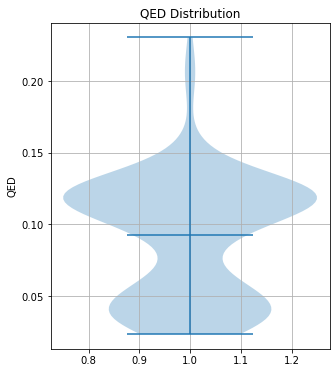

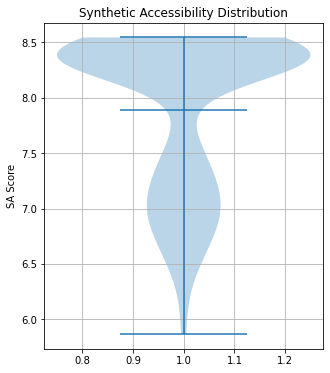

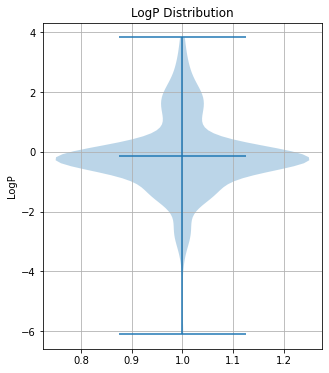

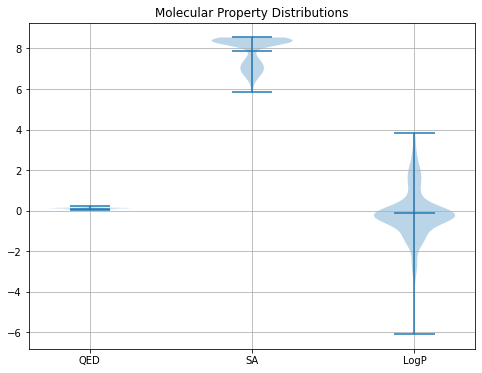

In [3]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_A_P_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("molecule_descriptors.csv", index=False)

print("\nSaved descriptor table as molecule_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

Found 818 XYZ files
                     Molecule       QED     LogP        SA
0  2output_221_Fragments_.xyz  0.136720 -0.78496  8.355009
1  2output_281_Fragments_.xyz  0.062803  0.77499  7.556551
2  2output_351_Fragments_.xyz  0.058233 -0.28975  6.707576
3  2output_418_Fragments_.xyz  0.127033 -0.79676  8.361083
4   1output_25_Fragments_.xyz  0.040763  2.33684  6.351296

Successfully processed: 818 molecules

Saved descriptor table as molecule_descriptors.csv


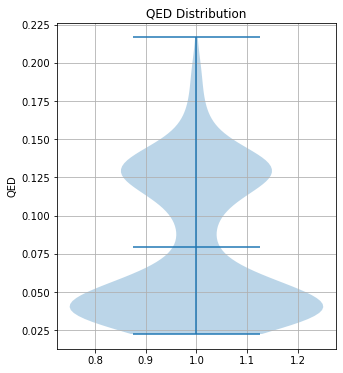

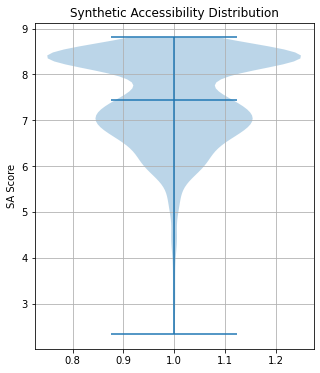

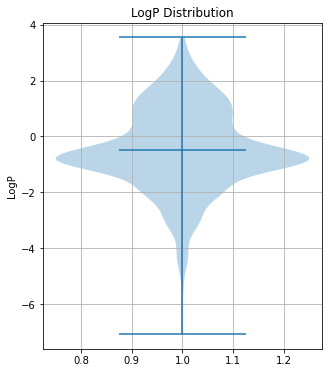

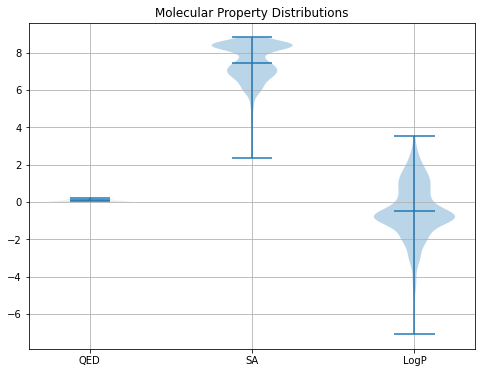

In [4]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_NA_P_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("molecule_descriptors.csv", index=False)

print("\nSaved descriptor table as molecule_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

Found 427 XYZ files
                     Molecule       QED     LogP        SA
0   1output_25_Fragments_.xyz  0.049651  0.91523  6.668530
1  1output_219_Fragments_.xyz  0.069055 -1.45816  6.893937
2   1output_44_Fragments_.xyz  0.028536 -2.04608  7.294938
3  1output_141_Fragments_.xyz  0.198960 -0.54109  8.489981
4  1output_170_Fragments_.xyz  0.035602  0.96624  6.605039

Successfully processed: 427 molecules

Saved descriptor table as molecule_descriptors.csv


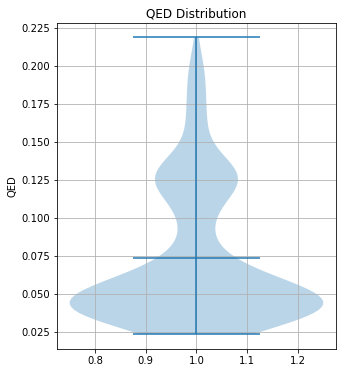

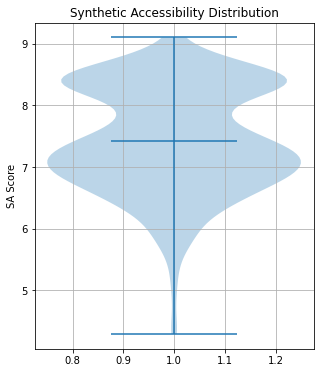

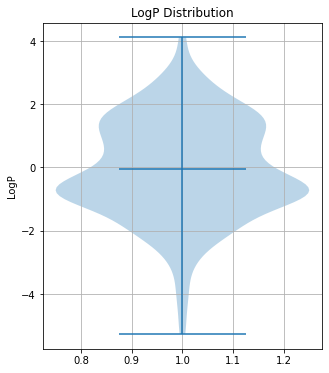

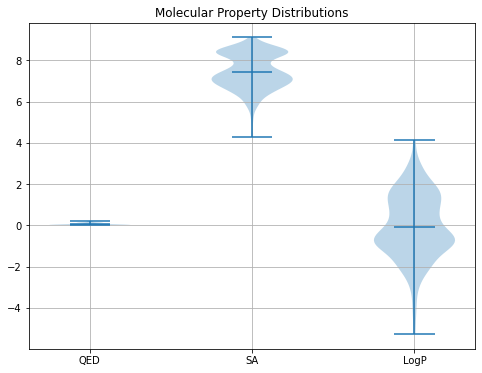

In [5]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_NA_NP_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("molecule_descriptors_NANP.csv", index=False)

print("\nSaved descriptor table as molecule_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

Found 279 XYZ files
                     Molecule       QED     LogP        SA
0  2output_281_Fragments_.xyz  0.026380 -3.08966  7.594743
1   1output_25_Fragments_.xyz  0.125238 -0.30290  8.361083
2  2output_298_Fragments_.xyz  0.036191  1.68855  6.755751
3  1output_409_Fragments_.xyz  0.109782 -2.56872  8.441712
4  2output_149_Fragments_.xyz  0.123729 -0.29001  8.392358

Successfully processed: 279 molecules

Saved descriptor table as molecule_descriptors_R_A_P.csv


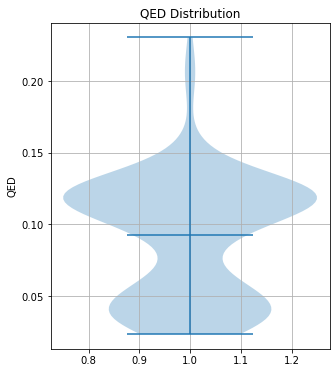

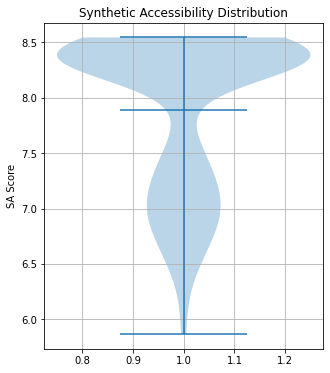

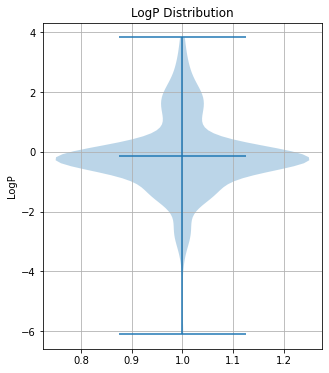

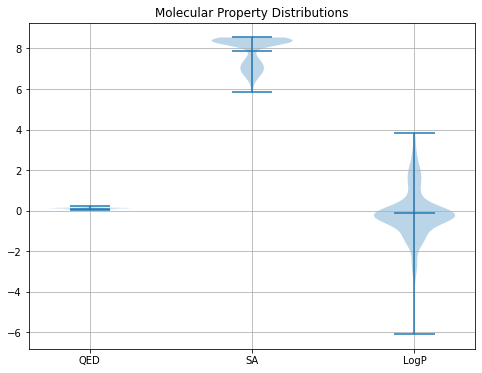

In [6]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_A_P_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("molecule_descriptors.csv", index=False)

print("\nSaved descriptor table as molecule_descriptors_R_A_P.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

Found 943 XYZ files
                     Molecule       QED     LogP        SA
0  2output_221_Fragments_.xyz  0.143384 -1.74220  8.433919
1  2output_281_Fragments_.xyz  0.051255  1.32462  6.892330
2  2output_351_Fragments_.xyz  0.047095  0.58455  6.777534
3  2output_418_Fragments_.xyz  0.077664 -2.26831  8.387480
4  2output_779_Fragments_.xyz  0.040601 -1.95438  6.449161

Successfully processed: 943 molecules

Saved descriptor table as molecule_descriptors.csv


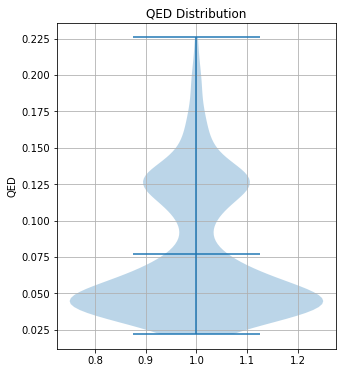

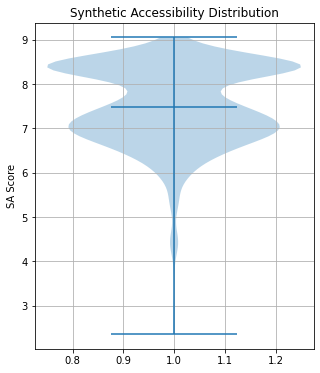

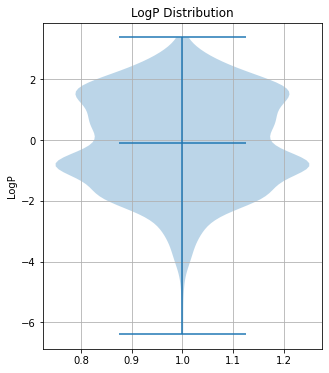

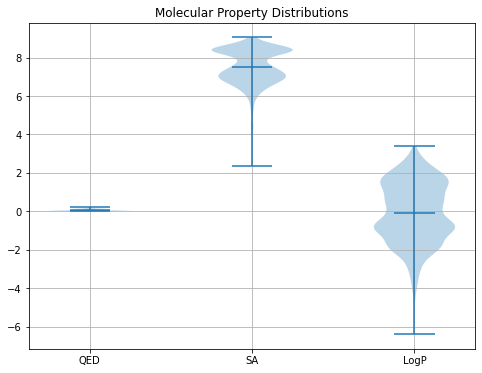

In [7]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_NA_NP_link/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("molecule_descriptors_link.csv", index=False)

print("\nSaved descriptor table as molecule_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

In [8]:
print(df[["QED", "SA", "LogP"]].describe())

              QED          SA        LogP
count  943.000000  943.000000  943.000000
mean     0.077294    7.488868   -0.082720
std      0.044304    0.932647    1.587959
min      0.022079    2.366629   -6.381160
25%      0.042611    6.892367   -1.135215
50%      0.053219    7.412972   -0.106650
75%      0.120810    8.339270    1.324620
max      0.225718    9.048661    3.378020


In [9]:
import pandas as pd

# Load CSV
df = pd.read_csv("molecule_descriptors.csv")

# Number of rows
num_rows = len(df)

print(f"Number of rows: {num_rows}")

Number of rows: 279


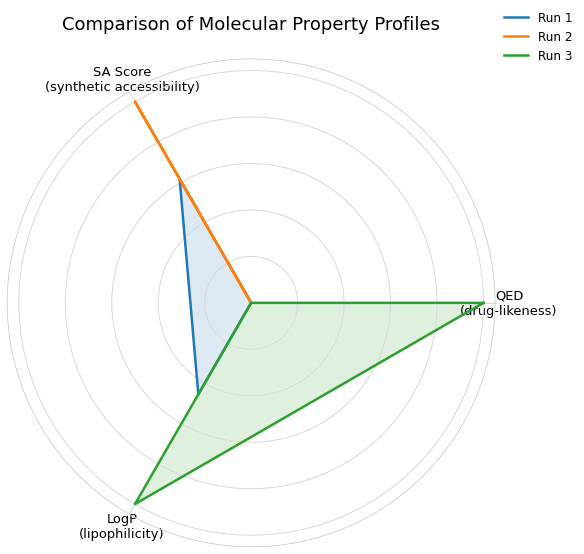

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Data
# -----------------------------------
categories = [
    "QED\n(drug-likeness)",
    "SA Score\n(synthetic accessibility)",
    "LogP\n(lipophilicity)"
]

run1 = [0.076, 7.50, -0.1]
run2 = [0.076, 7.25, -0.2]
run3 = [0.097, 7.90,  0.0]

# -----------------------------------
# Normalize values
# (important because scales differ)
# -----------------------------------

# Higher is better for QED
qed_vals = [run1[0], run2[0], run3[0]]

# LOWER is better for SA
# invert during normalization
sa_vals = [run1[1], run2[1], run3[1]]

# Ideal LogP close to 0
# convert to closeness-to-zero score
logp_vals = [run1[2], run2[2], run3[2]]

# Normalize manually
def normalize(vals):
    vmin = min(vals)
    vmax = max(vals)
    return [(v - vmin) / (vmax - vmin + 1e-9) for v in vals]

# QED normal
qed_norm = normalize(qed_vals)

# SA inverted (lower better)
sa_norm_raw = normalize(sa_vals)
sa_norm = [1 - x for x in sa_norm_raw]

# LogP closeness to zero
logp_score = [1 / (1 + abs(v)) for v in logp_vals]
logp_norm = normalize(logp_score)

# Final normalized runs
run1_norm = [qed_norm[0], sa_norm[0], logp_norm[0]]
run2_norm = [qed_norm[1], sa_norm[1], logp_norm[1]]
run3_norm = [qed_norm[2], sa_norm[2], logp_norm[2]]

# -----------------------------------
# Radar setup
# -----------------------------------
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Close polygons
run1_plot = run1_norm + run1_norm[:1]
run2_plot = run2_norm + run2_norm[:1]
run3_plot = run3_norm + run3_norm[:1]

# -----------------------------------
# Figure
# -----------------------------------
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Clean white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Grid styling
ax.grid(color="#d9d9d9", linewidth=1)
ax.spines['polar'].set_color("#cccccc")

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13)

# Remove radial labels
ax.set_yticklabels([])

# -----------------------------------
# Plot runs
# -----------------------------------
ax.plot(angles, run1_plot, linewidth=2.5, label="Run 1")
ax.fill(angles, run1_plot, alpha=0.15)

ax.plot(angles, run2_plot, linewidth=2.5, label="Run 2")
ax.fill(angles, run2_plot, alpha=0.15)

ax.plot(angles, run3_plot, linewidth=2.5, label="Run 3")
ax.fill(angles, run3_plot, alpha=0.15)

# -----------------------------------
# Title and legend
# -----------------------------------
plt.title(
    "Comparison of Molecular Property Profiles",
    fontsize=18,
    pad=30
)

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1.18, 1.12),
    frameon=False,
    fontsize=12
)

# -----------------------------------
# Layout
# -----------------------------------
plt.tight_layout()

# Save high-quality image
plt.savefig(
    "clean_spider_plot.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

[geom] Processing 943 files...


[02:47:52] Explicit valence for atom # 4 N, 4, is greater than permitted
[02:47:52] Explicit valence for atom # 33 N, 4, is greater than permitted
[02:47:52] Explicit valence for atom # 32 C, 5, is greater than permitted
[02:47:52] Explicit valence for atom # 4 N, 4, is greater than permitted
[02:47:52] Explicit valence for atom # 34 N, 4, is greater than permitted
[02:47:52] Explicit valence for atom # 36 N, 4, is greater than permitted
[02:47:52] Explicit valence for atom # 31 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 29 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 33 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 31 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 38 C, 5, is greater than permitted
[02:47:53] Explicit valence for atom # 34 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 7 N, 4, is greater than permitted
[02:47:53] Explicit valence for atom # 31

  Fingerprints computed: 916
[pocket] Processing 818 files...


[02:47:55] Explicit valence for atom # 5 C, 5, is greater than permitted


  Fingerprints computed: 816
[pocket_anchor] Processing 279 files...
  Fingerprints computed: 279

Total molecules: 2011

Running UMAP (Jaccard metric on Morgan fingerprints)...
UMAP(angular_rp_forest=True, metric='jaccard', random_state=42, verbose=True)
Thu May  7 02:47:56 2026 Construct fuzzy simplicial set


/home/rajnish/miniconda3/envs/difflinker/lib/python3.10/site-packages/umap/umap_.py:1879: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/home/rajnish/miniconda3/envs/difflinker/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Thu May  7 02:48:06 2026 Finding Nearest Neighbors
Thu May  7 02:48:09 2026 Finished Nearest Neighbor Search
Thu May  7 02:48:11 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu May  7 02:48:16 2026 Finished embedding
UMAP done.


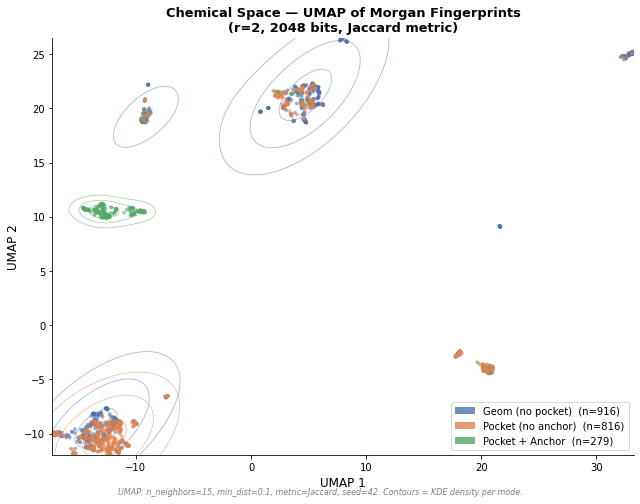

Saved fig_umap.png and fig_umap.pdf


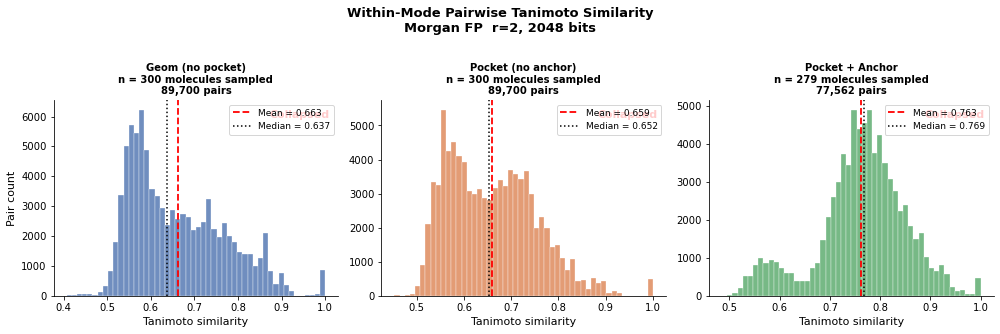

Saved fig_tanimoto.png and fig_tanimoto.pdf

=== Tanimoto Summary ===
Mode                  N sampled      Pairs     Mean   Median      Std
Geom (no pocket)            300      89700    0.663    0.637    0.109
Pocket (no anchor)          300      89700    0.659    0.652    0.094
Pocket + Anchor             279      77562    0.763    0.769    0.089


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from openbabel import pybel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.DataStructs import BulkTanimotoSimilarity
import umap

# ── CONFIG ───────────────────────────────────────────────────────────────────

MODE_DIRS = {
    "geom": Path("final_R_NA_NP_link/"),
    "pocket": Path("final_R_NA_P_1/"),
    "pocket_anchor": Path("final_R_A_P_1/"),
}
MODE_LABELS = {
    "geom":          "Geom (no pocket)",
    "pocket":        "Pocket (no anchor)",
    "pocket_anchor": "Pocket + Anchor",
}
MODE_COLORS = {
    "geom":          "#4C72B0",
    "pocket":        "#DD8452",
    "pocket_anchor": "#55A868",
}

MORGAN_RADIUS  = 2
MORGAN_BITS    = 2048
TANIMOTO_SAMPLE = 300   # molecules sampled per mode for pairwise Tanimoto
                         # (full pairwise on 1000 mols = 500k pairs, slow)
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST  = 0.1
SEED           = 42

# ── STEP 1: XYZ → fingerprint ────────────────────────────────────────────────

def xyz_to_fp(xyz_path):
    """
    XYZ → OpenBabel SMILES → RDKit mol → Morgan fingerprint.
    Returns (fp, smiles) or (None, None) on any failure.
    """
    try:
        ob_mol = next(pybel.readfile("xyz", str(xyz_path)))
        ob_mol.addh()
        smiles = ob_mol.write("can").strip().split()[0]
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, None
        Chem.SanitizeMol(mol)
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=MORGAN_RADIUS, nBits=MORGAN_BITS
        )
        return fp, smiles
    except Exception:
        return None, None


# ── STEP 2: Load all modes ────────────────────────────────────────────────────

all_fps    = []   # RDKit ExplicitBitVect objects
all_modes  = []   # mode string per molecule
all_smiles = []   # for reference

for mode, xyz_dir in MODE_DIRS.items():
    xyz_files = sorted(xyz_dir.glob("*.xyz"))
    ok = 0
    print(f"[{mode}] Processing {len(xyz_files)} files...")
    for xyz_path in xyz_files:
        fp, smi = xyz_to_fp(xyz_path)
        if fp is not None:
            all_fps.append(fp)
            all_modes.append(mode)
            all_smiles.append(smi)
            ok += 1
    print(f"  Fingerprints computed: {ok}")

print(f"\nTotal molecules: {len(all_fps)}")

# Convert to numpy array (needed for UMAP)
X = np.zeros((len(all_fps), MORGAN_BITS), dtype=np.uint8)
for i, fp in enumerate(all_fps):
    DataStructs.ConvertToNumpyArray(fp, X[i])

modes_arr = np.array(all_modes)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — UMAP 2D scatter
# ─────────────────────────────────────────────────────────────────────────────

print("\nRunning UMAP (Jaccard metric on Morgan fingerprints)...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="jaccard",       # correct metric for binary fingerprints
    random_state=SEED,
    verbose=True,
)
embedding = reducer.fit_transform(X)
print("UMAP done.")

fig, ax = plt.subplots(figsize=(9, 7))

for mode in MODE_DIRS:
    mask = modes_arr == mode
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=MODE_COLORS[mode],
        label=MODE_LABELS[mode],
        s=14,
        alpha=0.55,
        edgecolors="none",
        rasterized=True,    # keeps PDF file size small for thesis
    )

# Per-mode density contours (optional but makes the figure richer)
try:
    from scipy.stats import gaussian_kde
    for mode in MODE_DIRS:
        mask = modes_arr == mode
        xy = embedding[mask].T
        if xy.shape[1] < 10:
            continue
        kde = gaussian_kde(xy, bw_method=0.3)
        xmin, xmax = embedding[:, 0].min(), embedding[:, 0].max()
        ymin, ymax = embedding[:, 1].min(), embedding[:, 1].max()
        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=3,
                   colors=MODE_COLORS[mode], linewidths=0.8, alpha=0.5)
except Exception:
    pass   # contours are optional; skip silently if kde fails

ax.set_xlabel("UMAP 1", fontsize=12)
ax.set_ylabel("UMAP 2", fontsize=12)
ax.set_title(
    f"Chemical Space — UMAP of Morgan Fingerprints\n"
    f"(r={MORGAN_RADIUS}, {MORGAN_BITS} bits, Jaccard metric)",
    fontsize=13, fontweight="bold"
)

legend_handles = [
    mpatches.Patch(facecolor=MODE_COLORS[m], alpha=0.8,
                   label=f"{MODE_LABELS[m]}  (n={int((modes_arr == m).sum())})")
    for m in MODE_DIRS
]
ax.legend(handles=legend_handles, fontsize=10,
          framealpha=0.9, edgecolor="lightgray")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5, 0.01,
    f"UMAP: n_neighbors={UMAP_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, "
    f"metric=Jaccard, seed={SEED}. Contours = KDE density per mode.",
    ha="center", fontsize=8, color="gray", style="italic"
)

plt.tight_layout()
plt.savefig("fig_umap.png", dpi=200, bbox_inches="tight")
plt.savefig("fig_umap.pdf", bbox_inches="tight")   # vector for thesis
plt.show()
print("Saved fig_umap.png and fig_umap.pdf")


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Tanimoto similarity histogram (within-mode pairwise)
# ─────────────────────────────────────────────────────────────────────────────

# Full pairwise on N molecules = N*(N-1)/2 comparisons.
# 1000 mols → 500k pairs (slow). We sample TANIMOTO_SAMPLE per mode.
# If your mode has <300 mols (pocket_anchor at 441 filtered) use all of them.

np.random.seed(SEED)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

summary_stats = {}

for ax, mode in zip(axes, MODE_DIRS):
    mode_fps = [fp for fp, m in zip(all_fps, all_modes) if m == mode]

    n_available = len(mode_fps)
    n_sample    = min(TANIMOTO_SAMPLE, n_available)
    idx         = np.random.choice(n_available, n_sample, replace=False)
    sampled_fps = [mode_fps[i] for i in idx]

    # BulkTanimotoSimilarity: for each molecule, compare against all others
    # This is O(n^2) but vectorized in RDKit C++ — fast for n ≤ 500
    sims = []
    for i in range(len(sampled_fps)):
        bulk = BulkTanimotoSimilarity(sampled_fps[i],
                                      sampled_fps[:i] + sampled_fps[i+1:])
        sims.extend(bulk)

    sims = np.array(sims)

    mean_sim   = sims.mean()
    median_sim = np.median(sims)
    std_sim    = sims.std()
    summary_stats[mode] = {
        "n_sampled": n_sample,
        "n_pairs":   len(sims),
        "mean":      mean_sim,
        "median":    median_sim,
        "std":       std_sim,
    }

    ax.hist(
        sims, bins=50,
        color=MODE_COLORS[mode], alpha=0.80,
        edgecolor="white", linewidth=0.4,
    )
    ax.axvline(mean_sim,   color="red",    lw=1.8, ls="--",
               label=f"Mean = {mean_sim:.3f}")
    ax.axvline(median_sim, color="black",  lw=1.5, ls=":",
               label=f"Median = {median_sim:.3f}")

    ax.set_xlabel("Tanimoto similarity", fontsize=11)
    ax.set_ylabel("Pair count" if ax == axes[0] else "", fontsize=11)
    ax.set_title(
        f"{MODE_LABELS[mode]}\n"
        f"n = {n_sample} molecules sampled\n"
        f"{len(sims):,} pairs",
        fontsize=10, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Diversity verdict annotation
    if mean_sim < 0.30:
        verdict, color = "Diverse", "green"
    elif mean_sim < 0.50:
        verdict, color = "Moderate", "orange"
    else:
        verdict, color = "Collapsed", "red"

    ax.text(0.97, 0.95, verdict,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=11, fontweight="bold", color=color)

plt.suptitle(
    "Within-Mode Pairwise Tanimoto Similarity\n"
    f"Morgan FP  r={MORGAN_RADIUS}, {MORGAN_BITS} bits",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_tanimoto.png", dpi=200, bbox_inches="tight")
plt.savefig("fig_tanimoto.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_tanimoto.png and fig_tanimoto.pdf")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== Tanimoto Summary ===")
print(f"{'Mode':<20} {'N sampled':>10} {'Pairs':>10} "
      f"{'Mean':>8} {'Median':>8} {'Std':>8}")
for mode, s in summary_stats.items():
    print(f"{MODE_LABELS[mode]:<20} {s['n_sampled']:>10} {s['n_pairs']:>10} "
          f"{s['mean']:>8.3f} {s['median']:>8.3f} {s['std']:>8.3f}")

[geom] Processing 943 files...
  OK: 943  |  Failed: 0
[pocket] Processing 818 files...
  OK: 818  |  Failed: 0
[pocket_anchor] Processing 279 files...
  OK: 279  |  Failed: 0


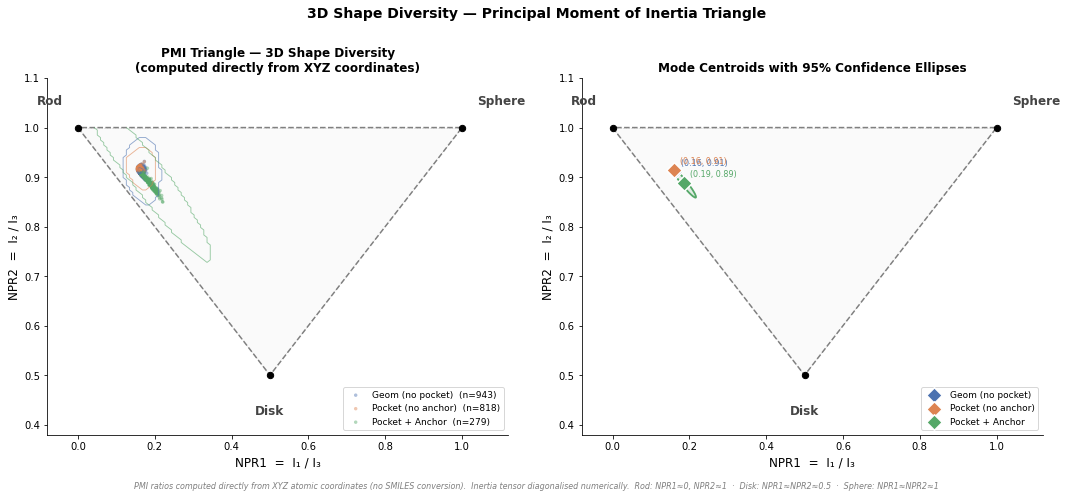

Saved fig_pmi_triangle.png / .pdf

=== PMI Shape Summary ===
Mode                        N  NPR1 mean   NPR1 std  NPR2 mean   NPR2 std     Shape bias
Geom (no pocket)          943      0.163      0.003      0.911      0.005       Rod-like
Pocket (no anchor)        818      0.160      0.003      0.915      0.003       Rod-like
Pocket + Anchor           279      0.186      0.013      0.889      0.012       Rod-like


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.tri import Triangulation
from pathlib import Path

# ── CONFIG ───────────────────────────────────────────────────────────────────

MODE_DIRS = {
    "geom": Path("final_R_NA_NP_link/"),
    "pocket": Path("final_R_NA_P_1/"),
    "pocket_anchor": Path("final_R_A_P_1/"),
}
MODE_LABELS = {
    "geom":          "Geom (no pocket)",
    "pocket":        "Pocket (no anchor)",
    "pocket_anchor": "Pocket + Anchor",
}
MODE_COLORS = {
    "geom":          "#4C72B0",
    "pocket":        "#DD8452",
    "pocket_anchor": "#55A868",
}

# ── ATOMIC MASSES (for inertia tensor) ───────────────────────────────────────
# Heavy atoms only — DiffLinker XYZ files typically omit H
ATOMIC_MASSES = {
    "H":  1.008,  "C":  12.011, "N":  14.007, "O":  15.999,
    "F":  18.998, "S":  32.060, "Cl": 35.450,  "Br": 79.904,
    "P":  30.974, "I": 126.904, "B":  10.811,  "Si": 28.086,
    "Se": 78.971, "Te":127.600,
}

# ── STEP 1: Parse XYZ ────────────────────────────────────────────────────────

def parse_xyz(xyz_path):
    """
    Read a .xyz file directly.
    Returns (elements: list[str], coords: ndarray shape (N,3))
    or (None, None) on failure.

    XYZ format:
      line 0 : atom count
      line 1 : comment (ignored)
      line 2+: element  x  y  z
    """
    try:
        with open(xyz_path) as f:
            lines = f.readlines()
        n_atoms = int(lines[0].strip())
        elements, coords = [], []
        for line in lines[2 : 2 + n_atoms]:
            parts = line.split()
            if len(parts) >= 4:
                elements.append(parts[0].capitalize())
                coords.append([float(parts[1]),
                                float(parts[2]),
                                float(parts[3])])
        if len(elements) < 3:        # need ≥3 atoms for a non-degenerate PMI
            return None, None
        return elements, np.array(coords, dtype=float)
    except Exception:
        return None, None


# ── STEP 2: PMI ratios from coordinates ──────────────────────────────────────

def calc_npr(elements, coords):
    """
    Compute NPR1 and NPR2 (normalized principal moment ratios)
    directly from XYZ atomic coordinates.

    Mathematics
    -----------
    Build the 3×3 inertia tensor, diagonalise to get
    principal moments  I1 ≤ I2 ≤ I3.

    NPR1 = I1/I3,  NPR2 = I2/I3

    Shape archetypes (triangle vertices):
      Rod    → NPR1 ≈ 0,   NPR2 ≈ 1    (one long axis, two tiny)
      Disk   → NPR1 ≈ 0.5, NPR2 ≈ 0.5  (flat, two large equal moments)
      Sphere → NPR1 ≈ 1,   NPR2 ≈ 1    (all moments equal)

    Valid region satisfies: NPR1 ≤ NPR2 and NPR1 + NPR2 ≥ 1
    (triangle inequality for moments of inertia).

    Returns (npr1, npr2) or (None, None).
    """
    masses = np.array([ATOMIC_MASSES.get(e, 12.0) for e in elements])
    total_mass = masses.sum()

    # Move to centre of mass
    com = (masses[:, None] * coords).sum(axis=0) / total_mass
    r = coords - com

    # Build inertia tensor  I_ab = Σ m_k (|r_k|² δ_ab − r_ka r_kb)
    I = np.zeros((3, 3))
    for m, ri in zip(masses, r):
        rsq = np.dot(ri, ri)
        I += m * (rsq * np.eye(3) - np.outer(ri, ri))

    # Principal moments — eigvalsh returns them sorted ascending
    eigvals = np.linalg.eigvalsh(I)
    I1, I2, I3 = eigvals                 # I1 ≤ I2 ≤ I3

    if I3 < 1e-10:                       # degenerate (linear/point molecule)
        return None, None

    npr1 = float(I1 / I3)
    npr2 = float(I2 / I3)

    # Numerical guard: clamp to valid range
    npr1 = max(0.0, min(npr1, 1.0))
    npr2 = max(0.0, min(npr2, 1.0))

    return npr1, npr2


# ── STEP 3: Load all modes ────────────────────────────────────────────────────

data = {mode: {"npr1": [], "npr2": []} for mode in MODE_DIRS}
failed = {mode: 0 for mode in MODE_DIRS}

for mode, xyz_dir in MODE_DIRS.items():
    xyz_files = sorted(xyz_dir.glob("*.xyz"))
    print(f"[{mode}] Processing {len(xyz_files)} files...")
    for xyz_path in xyz_files:
        elements, coords = parse_xyz(xyz_path)
        if elements is None:
            failed[mode] += 1
            continue
        npr1, npr2 = calc_npr(elements, coords)
        if npr1 is None:
            failed[mode] += 1
            continue
        data[mode]["npr1"].append(npr1)
        data[mode]["npr2"].append(npr2)
    n_ok = len(data[mode]["npr1"])
    print(f"  OK: {n_ok}  |  Failed: {failed[mode]}")


# ── STEP 4: PMI triangle plot ─────────────────────────────────────────────────

# Triangle vertices in (NPR1, NPR2) space
ROD    = np.array([0.0, 1.0])
DISK   = np.array([0.5, 0.5])
SPHERE = np.array([1.0, 1.0])
VERTS  = np.array([ROD, DISK, SPHERE])

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))


# ── Panel A: All modes overlaid ───────────────────────────────────────────────

ax = axes[0]

# Draw the PMI triangle boundary
triangle = plt.Polygon(VERTS, fill=False, edgecolor="gray",
                        linewidth=1.5, linestyle="--", zorder=1)
ax.add_patch(triangle)

# Shade the interior lightly
triangle_fill = plt.Polygon(VERTS, alpha=0.04, facecolor="gray", zorder=0)
ax.add_patch(triangle_fill)

# Draw internal reference lines (rod→sphere, disk→sphere)
for start, end in [(ROD, SPHERE), (DISK, ROD), (DISK, SPHERE)]:
    ax.plot([start[0], end[0]], [start[1], end[1]],
            color="gray", lw=0.6, ls=":", alpha=0.5, zorder=1)

# Scatter points per mode
for mode in MODE_DIRS:
    npr1 = np.array(data[mode]["npr1"])
    npr2 = np.array(data[mode]["npr2"])
    ax.scatter(npr1, npr2,
               c=MODE_COLORS[mode],
               label=f"{MODE_LABELS[mode]}  (n={len(npr1)})",
               s=12, alpha=0.45, edgecolors="none",
               rasterized=True, zorder=2)

# KDE contours per mode (optional — shows where each mode clusters)
try:
    from scipy.stats import gaussian_kde
    for mode in MODE_DIRS:
        npr1 = np.array(data[mode]["npr1"])
        npr2 = np.array(data[mode]["npr2"])
        if len(npr1) < 20:
            continue
        kde = gaussian_kde(np.vstack([npr1, npr2]), bw_method=0.25)
        x_grid = np.linspace(0, 1, 120)
        y_grid = np.linspace(0.4, 1, 120)
        xx, yy = np.meshgrid(x_grid, y_grid)
        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=3,
                   colors=MODE_COLORS[mode], linewidths=0.9, alpha=0.6, zorder=3)
except Exception:
    pass

# Vertex labels
offset = 0.04
ax.text(ROD[0] - offset,    ROD[1] + offset,    "Rod",    fontsize=12,
        fontweight="bold", color="#444", ha="right",  va="bottom")
ax.text(DISK[0],            DISK[1] - offset*1.5,"Disk",   fontsize=12,
        fontweight="bold", color="#444", ha="center", va="top")
ax.text(SPHERE[0] + offset, SPHERE[1] + offset,  "Sphere", fontsize=12,
        fontweight="bold", color="#444", ha="left",   va="bottom")

# Vertex markers
for v, label in zip(VERTS, ["Rod", "Disk", "Sphere"]):
    ax.scatter(*v, color="black", s=40, zorder=5)

ax.set_xlim(-0.08, 1.12)
ax.set_ylim(0.38, 1.10)
ax.set_xlabel("NPR1  =  I₁ / I₃", fontsize=12)
ax.set_ylabel("NPR2  =  I₂ / I₃", fontsize=12)
ax.set_title("PMI Triangle — 3D Shape Diversity\n(computed directly from XYZ coordinates)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.9, edgecolor="lightgray",
          loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ── Panel B: Per-mode subplots in a row inside one axis ──────────────────────
# Alternatively: three small triangles with density heatmap

ax2 = axes[1]

# Compute mean NPR1/NPR2 per mode for annotation
means = {}
for mode in MODE_DIRS:
    npr1 = np.array(data[mode]["npr1"])
    npr2 = np.array(data[mode]["npr2"])
    if len(npr1):
        means[mode] = (npr1.mean(), npr2.mean())

# Draw triangle
triangle2 = plt.Polygon(VERTS, fill=False, edgecolor="gray",
                         linewidth=1.5, linestyle="--", zorder=1)
ax2.add_patch(triangle2)
triangle_fill2 = plt.Polygon(VERTS, alpha=0.04, facecolor="gray", zorder=0)
ax2.add_patch(triangle_fill2)

for start, end in [(ROD, SPHERE), (DISK, ROD), (DISK, SPHERE)]:
    ax2.plot([start[0], end[0]], [start[1], end[1]],
             color="gray", lw=0.6, ls=":", alpha=0.5, zorder=1)

# Plot ONLY mean centroids with large markers + 95% ellipses
try:
    from matplotlib.patches import Ellipse
    from scipy.stats import chi2

    for mode in MODE_DIRS:
        npr1 = np.array(data[mode]["npr1"])
        npr2 = np.array(data[mode]["npr2"])
        if len(npr1) < 5:
            continue

        # 95% confidence ellipse
        cov = np.cov(npr1, npr2)
        eigvals_e, eigvecs_e = np.linalg.eigh(cov)
        order = eigvals_e.argsort()[::-1]
        eigvals_e, eigvecs_e = eigvals_e[order], eigvecs_e[:, order]
        angle = np.degrees(np.arctan2(*eigvecs_e[:, 0][::-1]))
        chi2_val = chi2.ppf(0.95, df=2)
        width, height = 2 * np.sqrt(eigvals_e * chi2_val)

        ellipse = Ellipse(xy=(npr1.mean(), npr2.mean()),
                          width=width, height=height, angle=angle,
                          edgecolor=MODE_COLORS[mode], facecolor=MODE_COLORS[mode],
                          alpha=0.15, linewidth=1.5, zorder=3)
        ax2.add_patch(ellipse)
        ellipse_border = Ellipse(xy=(npr1.mean(), npr2.mean()),
                                  width=width, height=height, angle=angle,
                                  edgecolor=MODE_COLORS[mode], facecolor="none",
                                  linewidth=1.8, zorder=4)
        ax2.add_patch(ellipse_border)

        # Mean centroid
        ax2.scatter(npr1.mean(), npr2.mean(),
                    color=MODE_COLORS[mode], s=120,
                    zorder=6, edgecolors="white", linewidth=1.5,
                    marker="D", label=f"{MODE_LABELS[mode]}")

        # Annotate mean values
        ax2.annotate(f"({npr1.mean():.2f}, {npr2.mean():.2f})",
                     xy=(npr1.mean(), npr2.mean()),
                     xytext=(6, 6), textcoords="offset points",
                     fontsize=8, color=MODE_COLORS[mode])

except Exception as e:
    print(f"Ellipse drawing failed: {e}. Plotting means only.")
    for mode in MODE_DIRS:
        if mode in means:
            ax2.scatter(*means[mode], color=MODE_COLORS[mode],
                        s=150, zorder=5, marker="D",
                        label=MODE_LABELS[mode], edgecolors="white", lw=1.5)

# Vertex labels
ax2.text(ROD[0] - offset,    ROD[1] + offset,    "Rod",    fontsize=12,
         fontweight="bold", color="#444", ha="right",  va="bottom")
ax2.text(DISK[0],            DISK[1] - offset*1.5,"Disk",   fontsize=12,
         fontweight="bold", color="#444", ha="center", va="top")
ax2.text(SPHERE[0] + offset, SPHERE[1] + offset,  "Sphere", fontsize=12,
         fontweight="bold", color="#444", ha="left",   va="bottom")

for v in VERTS:
    ax2.scatter(*v, color="black", s=40, zorder=5)

ax2.set_xlim(-0.08, 1.12)
ax2.set_ylim(0.38, 1.10)
ax2.set_xlabel("NPR1  =  I₁ / I₃", fontsize=12)
ax2.set_ylabel("NPR2  =  I₂ / I₃", fontsize=12)
ax2.set_title("Mode Centroids with 95% Confidence Ellipses",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, framealpha=0.9, edgecolor="lightgray",
           loc="lower right")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)


# ── Caption ───────────────────────────────────────────────────────────────────
fig.text(
    0.5, -0.02,
    "PMI ratios computed directly from XYZ atomic coordinates (no SMILES conversion).  "
    "Inertia tensor diagonalised numerically.  "
    "Rod: NPR1≈0, NPR2≈1  ·  Disk: NPR1≈NPR2≈0.5  ·  Sphere: NPR1≈NPR2≈1",
    ha="center", fontsize=8, color="gray", style="italic"
)

plt.suptitle("3D Shape Diversity — Principal Moment of Inertia Triangle",
             fontsize=14, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("fig_pmi_triangle.png", dpi=200, bbox_inches="tight")
plt.savefig("fig_pmi_triangle.pdf", bbox_inches="tight")
plt.show()
print("Saved fig_pmi_triangle.png / .pdf")


# ── Summary stats table ───────────────────────────────────────────────────────

print("\n=== PMI Shape Summary ===")
print(f"{'Mode':<22} {'N':>6} {'NPR1 mean':>10} {'NPR1 std':>10} "
      f"{'NPR2 mean':>10} {'NPR2 std':>10} {'Shape bias':>14}")

def shape_label(npr1_mean, npr2_mean):
    # Distance to each vertex in NPR space
    d_rod    = np.hypot(npr1_mean - 0.0, npr2_mean - 1.0)
    d_disk   = np.hypot(npr1_mean - 0.5, npr2_mean - 0.5)
    d_sphere = np.hypot(npr1_mean - 1.0, npr2_mean - 1.0)
    closest  = np.argmin([d_rod, d_disk, d_sphere])
    return ["Rod-like", "Disk-like", "Sphere-like"][closest]

for mode in MODE_DIRS:
    npr1 = np.array(data[mode]["npr1"])
    npr2 = np.array(data[mode]["npr2"])
    if not len(npr1):
        continue
    label = shape_label(npr1.mean(), npr2.mean())
    print(f"{MODE_LABELS[mode]:<22} {len(npr1):>6} "
          f"{npr1.mean():>10.3f} {npr1.std():>10.3f} "
          f"{npr2.mean():>10.3f} {npr2.std():>10.3f} {label:>14}")

In [14]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_A_P_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("_R_A_P_1_descriptors.csv", index=False)

print("\nSaved descriptor table as _R_A_P_1_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()

Found 279 XYZ files


KeyboardInterrupt: 

In [15]:
import os
import glob
import pandas as pd
import networkx as nx

from rdkit import Chem
from rdkit.Chem import rdDetermineBonds

# =========================================================
# SETTINGS
# =========================================================

xyz_folder = "final_R_A_P_1/"          # folder containing generated .xyz files
fragment_sdf = "Fragments.sdf"    # original two-fragment sdf

output_csv = "linker_R_A_P_1.csv"

# =========================================================
# LOAD ORIGINAL FRAGMENTS
# =========================================================

frag_mol = Chem.SDMolSupplier(fragment_sdf, removeHs=False)[0]

if frag_mol is None:
    raise ValueError("Could not read fragment SDF.")

# Get connected components of fragments
frag_components = Chem.GetMolFrags(frag_mol)

if len(frag_components) != 2:
    raise ValueError(
        f"Expected exactly 2 disconnected fragments, found {len(frag_components)}"
    )

fragment_atoms = set(frag_components[0]) | set(frag_components[1])

print(f"Fragment 1 atoms: {len(frag_components[0])}")
print(f"Fragment 2 atoms: {len(frag_components[1])}")

# =========================================================
# FUNCTION: XYZ -> RDKit molecule
# =========================================================

def xyz_to_mol(xyz_path):

    with open(xyz_path, "r") as f:
        xyz_block = f.read()

    mol = Chem.MolFromXYZBlock(xyz_block)

    if mol is None:
        return None

    try:
        rdDetermineBonds.DetermineConnectivity(mol)
    except:
        return None

    return mol

# =========================================================
# FUNCTION: GET LINKER LENGTH
# =========================================================

def get_linker_length(mol):

    # Build graph
    G = nx.Graph()

    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        G.add_edge(a1, a2)

    # Original fragment atom sets
    frag1 = set(frag_components[0])
    frag2 = set(frag_components[1])

    # Find all shortest paths between fragments
    shortest = None

    for a in frag1:
        for b in frag2:

            try:
                path = nx.shortest_path(G, a, b)

                if shortest is None or len(path) < len(shortest):
                    shortest = path

            except:
                continue

    if shortest is None:
        return None

    # Linker atoms are atoms BETWEEN fragments
    linker_length = len(shortest) - 2

    return max(linker_length, 0)

# =========================================================
# PROCESS ALL XYZ FILES
# =========================================================

results = []

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"\nFound {len(xyz_files)} XYZ files\n")

for xyz in xyz_files:

    try:
        mol = xyz_to_mol(xyz)

        if mol is None:
            continue

        linker_length = get_linker_length(mol)

        results.append({
            "Molecule": os.path.basename(xyz),
            "Linker_Length": linker_length
        })

        print(f"{os.path.basename(xyz)} --> {linker_length}")

    except Exception as e:
        print(f"Failed: {xyz}")
        print(e)

# =========================================================
# SAVE CSV
# =========================================================

df = pd.DataFrame(results)

df.to_csv(output_csv, index=False)

print(f"\nSaved results to: {output_csv}")

Fragment 1 atoms: 22
Fragment 2 atoms: 30

Found 279 XYZ files

2output_281_Fragments_.xyz --> 0
1output_25_Fragments_.xyz --> 0
2output_298_Fragments_.xyz --> 0
1output_409_Fragments_.xyz --> 0
2output_149_Fragments_.xyz --> 0
2output_267_Fragments_.xyz --> 0
1output_354_Fragments_.xyz --> 0
2output_367_Fragments_.xyz --> 0
2output_92_Fragments_.xyz --> 0
2output_74_Fragments_.xyz --> 0
1output_506_Fragments_.xyz --> 0
1output_396_Fragments_.xyz --> 0
2output_56_Fragments_.xyz --> 0
2output_284_Fragments_.xyz --> 0
2output_22_Fragments_.xyz --> 0
1output_313_Fragments_.xyz --> 0
2output_178_Fragments_.xyz --> 0
1output_116_Fragments_.xyz --> 0
2output_157_Fragments_.xyz --> 0
2output_29_Fragments_.xyz --> 0
1output_359_Fragments_.xyz --> 0
1output_38_Fragments_.xyz --> 0
1output_151_Fragments_.xyz --> 0
1output_163_Fragments_.xyz --> 0
2output_363_Fragments_.xyz --> 0
1output_179_Fragments_.xyz --> 0
1output_425_Fragments_.xyz --> 0
1output_297_Fragments_.xyz --> 0
2output_144_Fragmen

2output_143_Fragments_.xyz --> 0
2output_148_Fragments_.xyz --> 0
2output_114_Fragments_.xyz --> 0
1output_371_Fragments_.xyz --> 0
1output_289_Fragments_.xyz --> 0
2output_131_Fragments_.xyz --> 0
1output_388_Fragments_.xyz --> 0
2output_314_Fragments_.xyz --> 0
1output_65_Fragments_.xyz --> 0
1output_428_Fragments_.xyz --> 0
2output_417_Fragments_.xyz --> 0
1output_245_Fragments_.xyz --> 0
1output_142_Fragments_.xyz --> 0
1output_68_Fragments_.xyz --> 0
1output_156_Fragments_.xyz --> 0
1output_505_Fragments_.xyz --> 0
2output_400_Fragments_.xyz --> 0
2output_183_Fragments_.xyz --> 0
2output_68_Fragments_.xyz --> 0
1output_283_Fragments_.xyz --> 0
2output_276_Fragments_.xyz --> 0
2output_361_Fragments_.xyz --> 0

Saved results to: linker_R_A_P_1.csv


In [17]:
import os
import glob
import pandas as pd
import networkx as nx

from rdkit import Chem
from rdkit.Chem import rdDetermineBonds

# =========================================================
# SETTINGS
# =========================================================

xyz_folder = "final_R_NA_P_1/"          # folder containing generated .xyz files
fragment_sdf = "Fragments.sdf"    # original two-fragment sdf

output_csv = "linker_R_NA_P_1.csv"

# =========================================================
# LOAD ORIGINAL FRAGMENTS
# =========================================================

frag_mol = Chem.SDMolSupplier(fragment_sdf, removeHs=False)[0]

if frag_mol is None:
    raise ValueError("Could not read fragment SDF")

# Get disconnected fragments
frag_frags = Chem.GetMolFrags(frag_mol)

if len(frag_frags) != 2:
    raise ValueError(
        f"Expected 2 disconnected fragments, got {len(frag_frags)}"
    )

frag1_atoms = set(frag_frags[0])
frag2_atoms = set(frag_frags[1])

print("Fragment 1 atoms:", frag1_atoms)
print("Fragment 2 atoms:", frag2_atoms)

# =========================================================
# XYZ -> MOL
# =========================================================

def xyz_to_mol(xyz_path):

    with open(xyz_path, "r") as f:
        xyz_block = f.read()

    mol = Chem.MolFromXYZBlock(xyz_block)

    if mol is None:
        return None

    try:
        rdDetermineBonds.DetermineConnectivity(mol)
    except:
        return None

    return mol

# =========================================================
# FIND LINKER LENGTH
# =========================================================

def get_linker_length(mol):

    # Build graph
    G = nx.Graph()

    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        G.add_edge(a1, a2)

    # -----------------------------------------------------
    # IMPORTANT:
    # Fragment atoms occupy SAME atom indices in generated
    # structures for DiffLinker outputs
    # -----------------------------------------------------

    shortest_path = None

    for a in frag1_atoms:
        for b in frag2_atoms:

            try:
                path = nx.shortest_path(G, a, b)

                # We ONLY want paths that actually pass
                # through linker atoms
                if len(path) <= 2:
                    continue

                if shortest_path is None or len(path) < len(shortest_path):
                    shortest_path = path

            except:
                continue

    if shortest_path is None:
        return 0

    # -----------------------------------------------------
    # Linker atoms:
    # atoms NOT belonging to original fragments
    # -----------------------------------------------------

    linker_atoms = [
        atom for atom in shortest_path
        if atom not in frag1_atoms
        and atom not in frag2_atoms
    ]

    return len(linker_atoms)

# =========================================================
# PROCESS FILES
# =========================================================

results = []

xyz_files = sorted(glob.glob(os.path.join(xyz_folder, "*.xyz")))

print(f"\nFound {len(xyz_files)} xyz files\n")

for xyz in xyz_files:

    try:

        mol = xyz_to_mol(xyz)

        if mol is None:
            print(f"Failed reading {xyz}")
            continue

        linker_len = get_linker_length(mol)

        results.append({
            "Molecule": os.path.basename(xyz),
            "Linker_Length": linker_len
        })

        print(
            f"{os.path.basename(xyz)} --> linker length = {linker_len}"
        )

    except Exception as e:
        print(f"ERROR: {xyz}")
        print(e)

# =========================================================
# SAVE
# =========================================================

df = pd.DataFrame(results)

df.to_csv(output_csv, index=False)

print(f"\nSaved: {output_csv}")

Fragment 1 atoms: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21}
Fragment 2 atoms: {22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51}

Found 818 xyz files

1output_0_Fragments_.xyz --> linker length = 1
1output_100_Fragments_.xyz --> linker length = 1
1output_101_Fragments_.xyz --> linker length = 0
1output_103_Fragments_.xyz --> linker length = 0
1output_105_Fragments_.xyz --> linker length = 0
1output_107_Fragments_.xyz --> linker length = 0
1output_108_Fragments_.xyz --> linker length = 1
1output_109_Fragments_.xyz --> linker length = 0
1output_10_Fragments_.xyz --> linker length = 1
1output_110_Fragments_.xyz --> linker length = 0
1output_111_Fragments_.xyz --> linker length = 0
1output_112_Fragments_.xyz --> linker length = 0
1output_113_Fragments_.xyz --> linker length = 0
1output_114_Fragments_.xyz --> linker length = 0
1output_115_Fragments_.xyz --> linker length = 0
1output_11

1output_291_Fragments_.xyz --> linker length = 0
1output_292_Fragments_.xyz --> linker length = 1
1output_293_Fragments_.xyz --> linker length = 0
1output_294_Fragments_.xyz --> linker length = 0
1output_295_Fragments_.xyz --> linker length = 1
1output_296_Fragments_.xyz --> linker length = 1
1output_297_Fragments_.xyz --> linker length = 0
1output_298_Fragments_.xyz --> linker length = 0
1output_299_Fragments_.xyz --> linker length = 0
1output_2_Fragments_.xyz --> linker length = 1
1output_300_Fragments_.xyz --> linker length = 1
1output_301_Fragments_.xyz --> linker length = 0
1output_303_Fragments_.xyz --> linker length = 0
1output_304_Fragments_.xyz --> linker length = 0
1output_305_Fragments_.xyz --> linker length = 0
1output_306_Fragments_.xyz --> linker length = 0
1output_307_Fragments_.xyz --> linker length = 1
1output_308_Fragments_.xyz --> linker length = 0
1output_309_Fragments_.xyz --> linker length = 1
1output_30_Fragments_.xyz --> linker length = 0
1output_310_Fragments_.

1output_475_Fragments_.xyz --> linker length = 1
1output_476_Fragments_.xyz --> linker length = 0
1output_477_Fragments_.xyz --> linker length = 1
1output_478_Fragments_.xyz --> linker length = 0
1output_479_Fragments_.xyz --> linker length = 1
1output_47_Fragments_.xyz --> linker length = 0
1output_480_Fragments_.xyz --> linker length = 1
1output_481_Fragments_.xyz --> linker length = 0
1output_482_Fragments_.xyz --> linker length = 1
1output_483_Fragments_.xyz --> linker length = 0
1output_484_Fragments_.xyz --> linker length = 0
1output_485_Fragments_.xyz --> linker length = 0
1output_486_Fragments_.xyz --> linker length = 0
1output_487_Fragments_.xyz --> linker length = 0
1output_488_Fragments_.xyz --> linker length = 0
1output_489_Fragments_.xyz --> linker length = 1
1output_490_Fragments_.xyz --> linker length = 0
1output_491_Fragments_.xyz --> linker length = 1
1output_492_Fragments_.xyz --> linker length = 1
1output_493_Fragments_.xyz --> linker length = 0
1output_495_Fragments

2output_213_Fragments_.xyz --> linker length = 0
2output_217_Fragments_.xyz --> linker length = 1
2output_218_Fragments_.xyz --> linker length = 0
2output_219_Fragments_.xyz --> linker length = 0
2output_221_Fragments_.xyz --> linker length = 0
2output_222_Fragments_.xyz --> linker length = 0
2output_223_Fragments_.xyz --> linker length = 0
2output_224_Fragments_.xyz --> linker length = 0
2output_227_Fragments_.xyz --> linker length = 0
2output_228_Fragments_.xyz --> linker length = 0
2output_229_Fragments_.xyz --> linker length = 0
2output_22_Fragments_.xyz --> linker length = 0
2output_230_Fragments_.xyz --> linker length = 0
2output_232_Fragments_.xyz --> linker length = 0
2output_233_Fragments_.xyz --> linker length = 1
2output_234_Fragments_.xyz --> linker length = 1
2output_235_Fragments_.xyz --> linker length = 1
2output_236_Fragments_.xyz --> linker length = 1
2output_237_Fragments_.xyz --> linker length = 0
2output_238_Fragments_.xyz --> linker length = 0
2output_239_Fragments

2output_421_Fragments_.xyz --> linker length = 1
2output_423_Fragments_.xyz --> linker length = 0
2output_424_Fragments_.xyz --> linker length = 1
2output_425_Fragments_.xyz --> linker length = 0
2output_426_Fragments_.xyz --> linker length = 1
2output_427_Fragments_.xyz --> linker length = 0
2output_428_Fragments_.xyz --> linker length = 0
2output_42_Fragments_.xyz --> linker length = 0
2output_430_Fragments_.xyz --> linker length = 0
2output_431_Fragments_.xyz --> linker length = 0
2output_433_Fragments_.xyz --> linker length = 0
2output_434_Fragments_.xyz --> linker length = 0
2output_435_Fragments_.xyz --> linker length = 0
2output_436_Fragments_.xyz --> linker length = 1
2output_437_Fragments_.xyz --> linker length = 0
2output_438_Fragments_.xyz --> linker length = 0
2output_439_Fragments_.xyz --> linker length = 1
2output_43_Fragments_.xyz --> linker length = 0
2output_440_Fragments_.xyz --> linker length = 0
2output_441_Fragments_.xyz --> linker length = 1
2output_442_Fragments_

In [18]:
import os
import glob
import pandas as pd
import networkx as nx

from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import rdFMCS

# =========================================================
# SETTINGS
# =========================================================

xyz_folder = "final_R_NA_P_1/"          # folder containing generated .xyz files
fragment_sdf = "Fragments.sdf"    # original two-fragment sdf

output_csv = "linker_R_NA_P_1.csv"

# =========================================================
# LOAD ORIGINAL TWO FRAGMENTS
# =========================================================

frag_mol = Chem.SDMolSupplier(
    fragment_sdf,
    removeHs=False
)[0]

if frag_mol is None:
    raise ValueError("Could not load fragment sdf")

# Split disconnected fragments
frag_parts = Chem.GetMolFrags(
    frag_mol,
    asMols=True,
    sanitizeFrags=False
)

if len(frag_parts) != 2:
    raise ValueError(
        f"Expected 2 disconnected fragments, got {len(frag_parts)}"
    )

frag1 = frag_parts[0]
frag2 = frag_parts[1]

print("Loaded 2 fragments")

# =========================================================
# XYZ -> RDKit MOL
# =========================================================

def xyz_to_mol(xyz_path):

    with open(xyz_path, "r") as f:
        xyz_block = f.read()

    mol = Chem.MolFromXYZBlock(xyz_block)

    if mol is None:
        return None

    try:
        rdDetermineBonds.DetermineConnectivity(mol)
    except:
        return None

    return mol

# =========================================================
# GET MATCHED FRAGMENT ATOMS
# =========================================================

def get_fragment_matches(gen_mol):

    # Match fragment 1
    match1 = gen_mol.GetSubstructMatch(frag1)

    # Match fragment 2
    match2 = gen_mol.GetSubstructMatch(frag2)

    if not match1 or not match2:
        return None, None

    return set(match1), set(match2)

# =========================================================
# GET LINKER LENGTH
# =========================================================

def get_linker_length(gen_mol):

    frag1_atoms, frag2_atoms = get_fragment_matches(gen_mol)

    if frag1_atoms is None:
        return None

    # Build molecular graph
    G = nx.Graph()

    for bond in gen_mol.GetBonds():

        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()

        G.add_edge(a1, a2)

    shortest_path = None

    # -----------------------------------------------------
    # Find shortest path between fragments
    # -----------------------------------------------------

    for a in frag1_atoms:
        for b in frag2_atoms:

            try:
                path = nx.shortest_path(G, a, b)

                if shortest_path is None:
                    shortest_path = path

                elif len(path) < len(shortest_path):
                    shortest_path = path

            except:
                pass

    if shortest_path is None:
        return None

    # -----------------------------------------------------
    # Linker atoms:
    # atoms NOT in either fragment
    # -----------------------------------------------------

    linker_atoms = [
        x for x in shortest_path
        if x not in frag1_atoms
        and x not in frag2_atoms
    ]

    return len(linker_atoms)

# =========================================================
# PROCESS ALL FILES
# =========================================================

results = []

xyz_files = sorted(
    glob.glob(os.path.join(xyz_folder, "*.xyz"))
)

print(f"\nFound {len(xyz_files)} xyz files\n")

for xyz in xyz_files:

    try:

        mol = xyz_to_mol(xyz)

        if mol is None:
            print(f"Failed: {xyz}")
            continue

        linker_length = get_linker_length(mol)

        results.append({
            "Molecule": os.path.basename(xyz),
            "Linker_Length": linker_length
        })

        print(
            f"{os.path.basename(xyz)} --> {linker_length}"
        )

    except Exception as e:

        print(f"ERROR: {xyz}")
        print(e)

# =========================================================
# SAVE CSV
# =========================================================

df = pd.DataFrame(results)

df.to_csv(output_csv, index=False)

print(f"\nSaved: {output_csv}")

Loaded 2 fragments

Found 818 xyz files

1output_0_Fragments_.xyz --> None
1output_100_Fragments_.xyz --> None
1output_101_Fragments_.xyz --> None
1output_103_Fragments_.xyz --> None
1output_105_Fragments_.xyz --> None
1output_107_Fragments_.xyz --> None
1output_108_Fragments_.xyz --> None
1output_109_Fragments_.xyz --> None
1output_10_Fragments_.xyz --> None
1output_110_Fragments_.xyz --> None
1output_111_Fragments_.xyz --> None
1output_112_Fragments_.xyz --> None
1output_113_Fragments_.xyz --> None
1output_114_Fragments_.xyz --> None
1output_115_Fragments_.xyz --> None
1output_116_Fragments_.xyz --> None
1output_119_Fragments_.xyz --> None
1output_120_Fragments_.xyz --> None
1output_122_Fragments_.xyz --> None
1output_123_Fragments_.xyz --> None
1output_124_Fragments_.xyz --> None
1output_126_Fragments_.xyz --> None
1output_127_Fragments_.xyz --> None
1output_128_Fragments_.xyz --> None
1output_129_Fragments_.xyz --> None
1output_12_Fragments_.xyz --> None
1output_130_Fragments_.xyz 

2output_330_Fragments_.xyz --> None
2output_333_Fragments_.xyz --> None
2output_334_Fragments_.xyz --> None
2output_335_Fragments_.xyz --> None
2output_336_Fragments_.xyz --> None
2output_338_Fragments_.xyz --> None
2output_339_Fragments_.xyz --> None
2output_33_Fragments_.xyz --> None
2output_340_Fragments_.xyz --> None
2output_342_Fragments_.xyz --> None
2output_343_Fragments_.xyz --> None
2output_345_Fragments_.xyz --> None
2output_347_Fragments_.xyz --> None
2output_348_Fragments_.xyz --> None
2output_349_Fragments_.xyz --> None
2output_34_Fragments_.xyz --> None
2output_351_Fragments_.xyz --> None
2output_352_Fragments_.xyz --> None
2output_353_Fragments_.xyz --> None
2output_354_Fragments_.xyz --> None
2output_356_Fragments_.xyz --> None
2output_358_Fragments_.xyz --> None
2output_359_Fragments_.xyz --> None
2output_35_Fragments_.xyz --> None
2output_360_Fragments_.xyz --> None
2output_361_Fragments_.xyz --> None
2output_362_Fragments_.xyz --> None
2output_363_Fragments_.xyz --> 

Loaded 818 molecules
Saved → ranked_moleculesR_NA_P_1.xlsx
Saved → composite_score.png


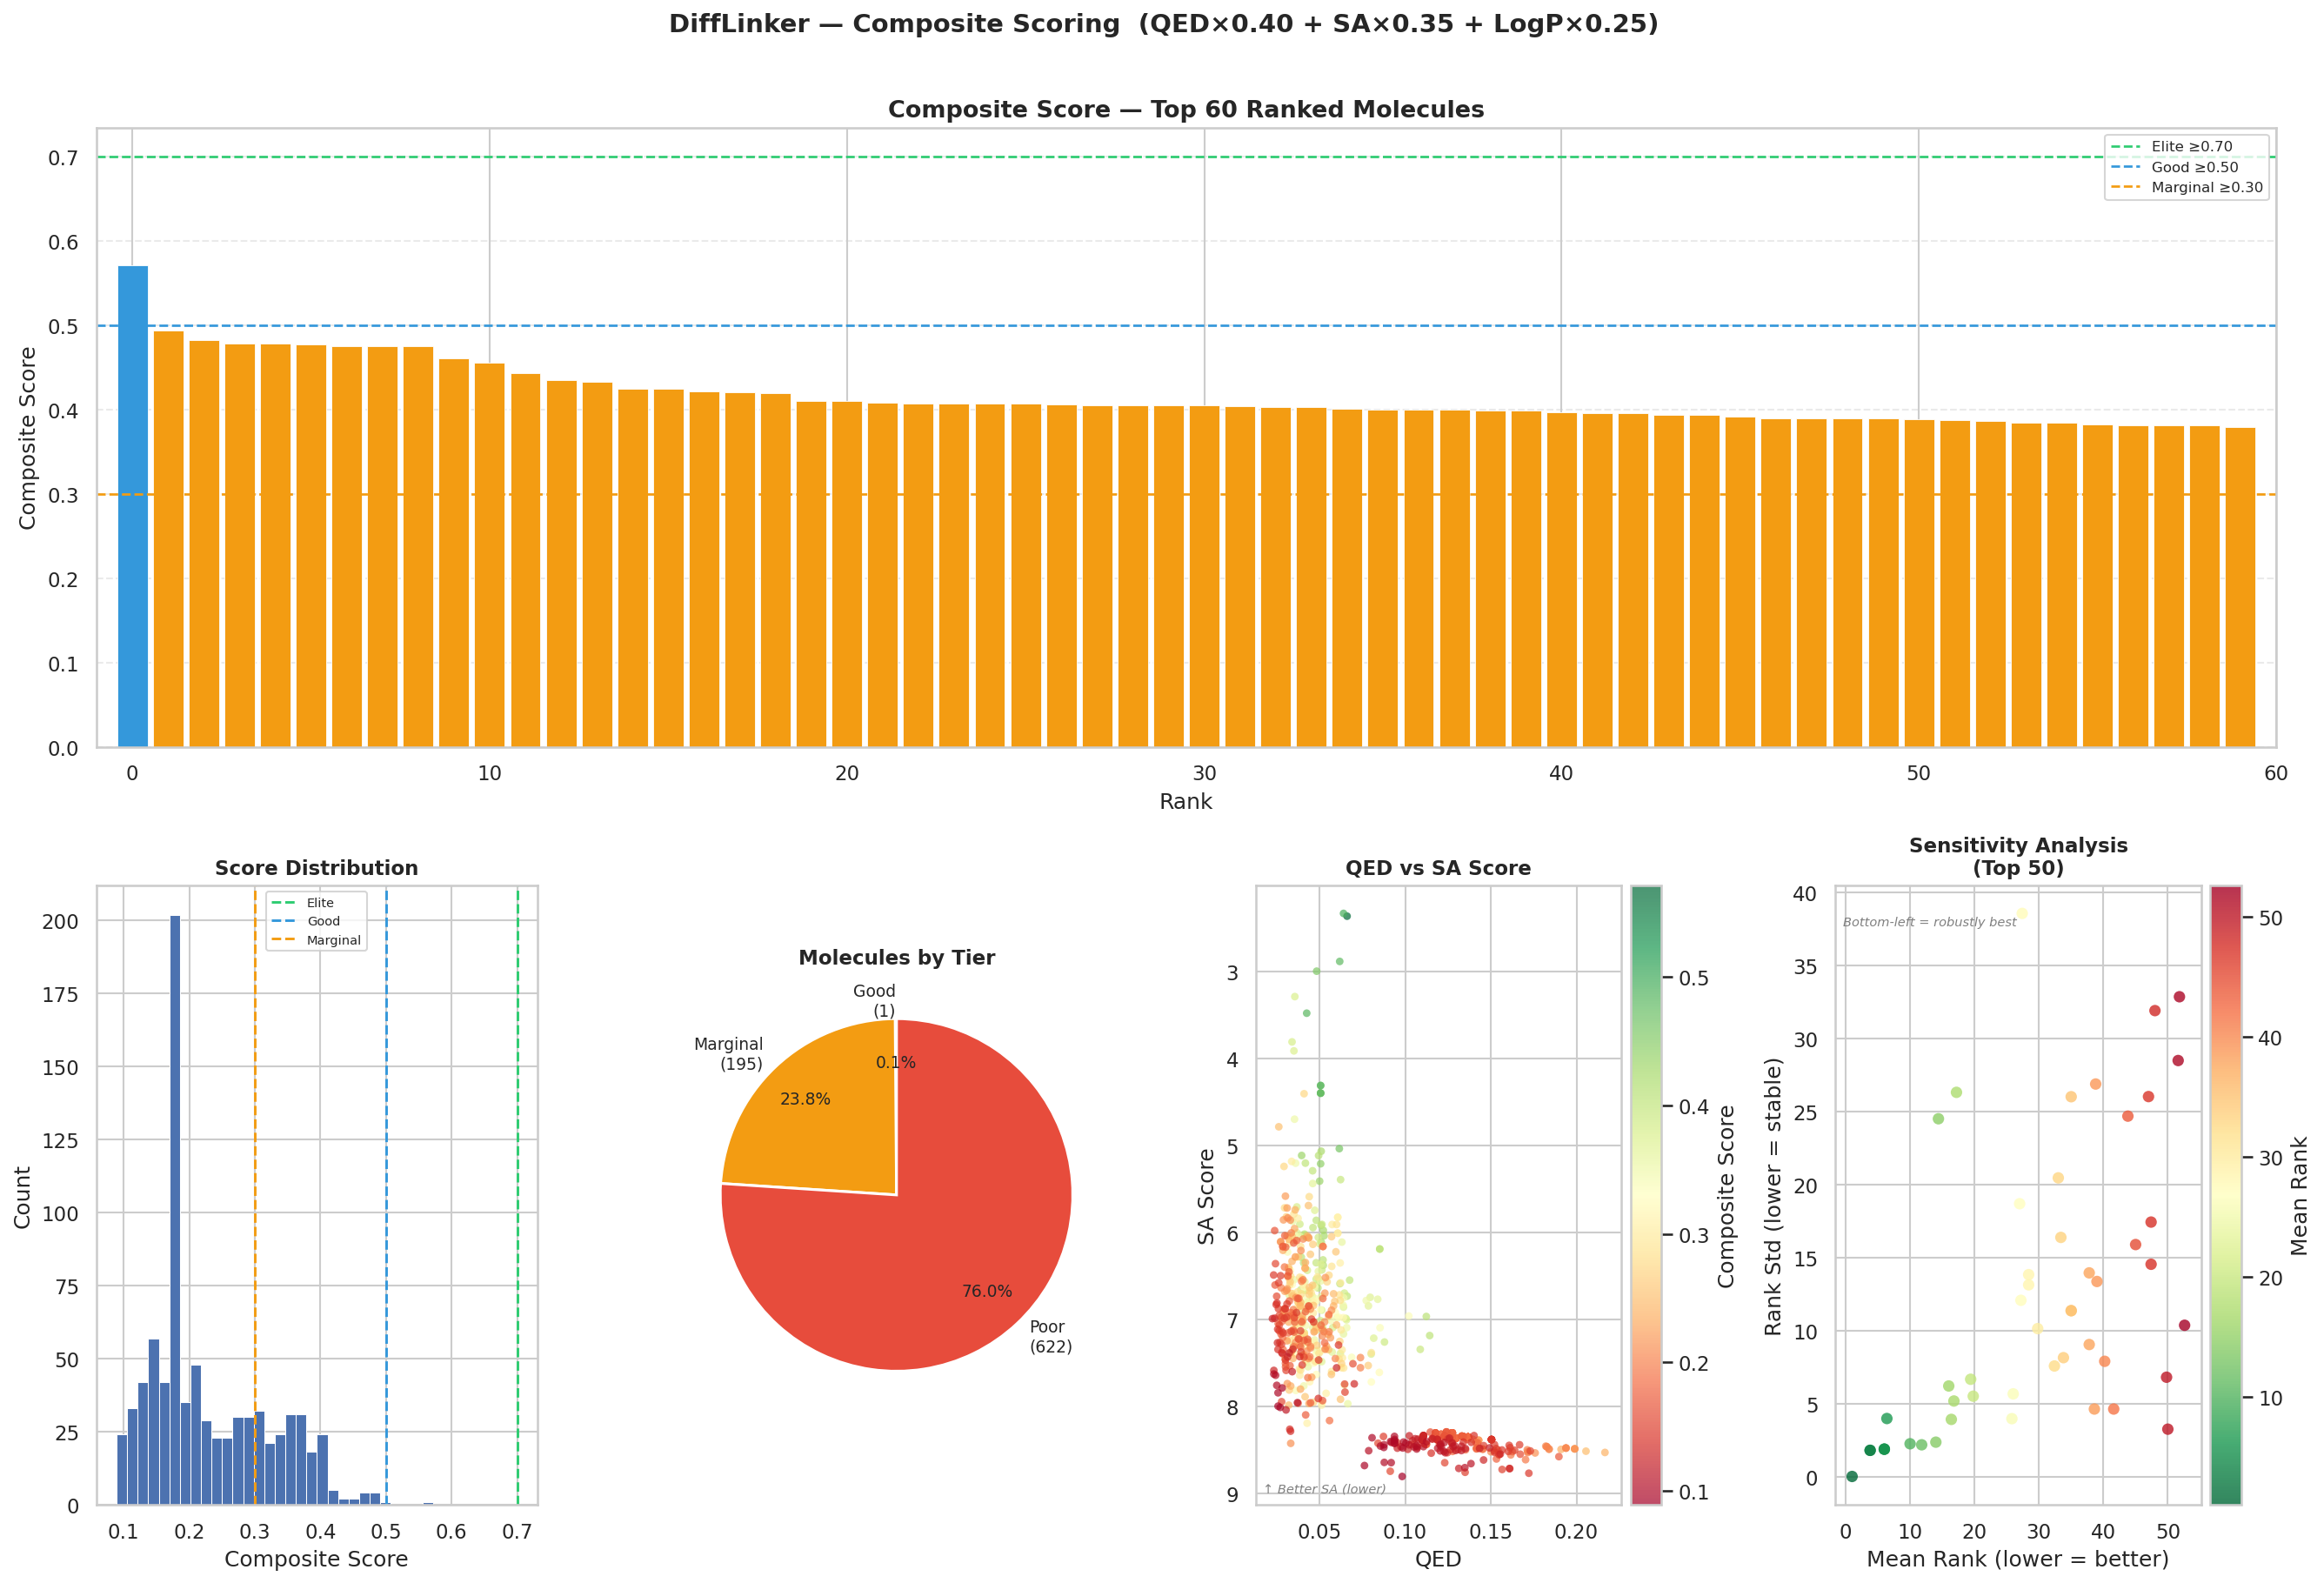


  TOP 20 MOLECULES
 rank                   Molecule      QED       SA    LogP  composite_score     tier
    1 1output_478_Fragments_.xyz 0.066108 2.366629 2.26695         0.571605     Good
    2 1output_205_Fragments_.xyz 0.064050 2.334860 0.74833         0.494069 Marginal
    3 1output_357_Fragments_.xyz 0.042544 3.481810 1.35965         0.482996 Marginal
    4 1output_219_Fragments_.xyz 0.050674 4.313279 1.84374         0.478317 Marginal
    4 2output_411_Fragments_.xyz 0.050674 4.313279 1.84374         0.478317 Marginal
    6  2output_72_Fragments_.xyz 0.061812 2.886811 0.82972         0.477745 Marginal
    7  1output_76_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
    7 1output_510_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
    7 2output_152_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
   10 2output_316_Fragments_.xyz 0.061578 5.038918 2.04107         0.461066 Marginal
   11 1output_171_Fragments_.xyz 0.048356 2.9

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

# ── SET YOUR FILE PATH HERE ───────────────────────────────────────────────────
INPUT_FILE  = 'R_NA_P_1_descriptors.csv'
OUTPUT_FILE = 'ranked_moleculesR_NA_P_1.xlsx'
PLOT_FILE   = 'composite_score.png'
# ─────────────────────────────────────────────────────────────────────────────


# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE)
df = df.dropna(subset=['QED', 'SA', 'LogP']).reset_index(drop=True)
print(f'Loaded {len(df)} molecules')


# ── SUB-SCORES ────────────────────────────────────────────────────────────────
df['score_qed']  = df['QED'].clip(0, 1)
df['score_sa']   = (10.0 - df['SA'].clip(1, 10)) / 9.0
df['score_logp'] = np.exp(-((df['LogP'] - 2.5) ** 2) / (2 * 2.0 ** 2))


# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
df['composite_score'] = (
    0.40 * df['score_qed'] +
    0.35 * df['score_sa']  +
    0.25 * df['score_logp']
).round(6)


# ── RANK & TIER ───────────────────────────────────────────────────────────────
df['rank'] = df['composite_score'].rank(ascending=False, method='min').astype(int)
df = df.sort_values('rank').reset_index(drop=True)

TIER_ORDER  = ['Elite', 'Good', 'Marginal', 'Poor']
TIER_COLORS = {'Elite': '#2ecc71', 'Good': '#3498db',
               'Marginal': '#f39c12', 'Poor': '#e74c3c'}

def assign_tier(s):
    if s >= 0.70: return 'Elite'
    if s >= 0.50: return 'Good'
    if s >= 0.30: return 'Marginal'
    return 'Poor'

df['tier'] = df['composite_score'].apply(assign_tier)
tiers_present = [t for t in TIER_ORDER if t in df['tier'].values]


# ── SENSITIVITY ANALYSIS ──────────────────────────────────────────────────────
schemes = {
    'Balanced':   (0.40, 0.35, 0.25),
    'QED-heavy':  (0.60, 0.25, 0.15),
    'SA-heavy':   (0.25, 0.60, 0.15),
    'LogP-heavy': (0.25, 0.25, 0.50),
    'Equal':      (0.333, 0.333, 0.334),
}

rank_df = pd.DataFrame({'Molecule': df['Molecule']})
for name, (wq, ws, wl) in schemes.items():
    s = wq * df['score_qed'] + ws * df['score_sa'] + wl * df['score_logp']
    rank_df[name] = s.rank(ascending=False, method='min').astype(int)

rank_df['rank_mean'] = rank_df[list(schemes.keys())].mean(axis=1).round(1)
rank_df['rank_std']  = rank_df[list(schemes.keys())].std(axis=1).round(2)
rank_df = rank_df.sort_values('rank_mean').reset_index(drop=True)


# ── SAVE EXCEL ────────────────────────────────────────────────────────────────
out_cols = ['rank', 'Molecule', 'QED', 'SA', 'LogP',
            'score_qed', 'score_sa', 'score_logp', 'composite_score', 'tier']

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df[out_cols].to_excel(writer, sheet_name='Ranked', index=False)
    df[out_cols].head(20).to_excel(writer, sheet_name='Top20', index=False)
    summary = (
        df.groupby('tier')[['QED', 'SA', 'LogP', 'composite_score']]
        .describe().round(3)
        .reindex([t for t in TIER_ORDER if t in df['tier'].values])
    )
    summary.to_excel(writer, sheet_name='Tier_Summary')
    rank_df.to_excel(writer, sheet_name='Sensitivity', index=False)

print(f'Saved → {OUTPUT_FILE}')


# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax2 = plt.subplot2grid((2, 4), (1, 0))
ax3 = plt.subplot2grid((2, 4), (1, 1))
ax4 = plt.subplot2grid((2, 4), (1, 2))
ax5 = plt.subplot2grid((2, 4), (1, 3))

# 1 — Ranked bar (top 60)
top60 = df.head(60)
ax1.bar(range(len(top60)), top60['composite_score'],
        color=[TIER_COLORS[t] for t in top60['tier']],
        edgecolor='white', linewidth=0.4, width=0.85)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite ≥0.70'),
                            (0.50, '#3498db', 'Good ≥0.50'),
                            (0.30, '#f39c12', 'Marginal ≥0.30')]:
    ax1.axhline(thresh, color=color, linestyle='--', linewidth=1.3, label=lbl)
ax1.set_title('Composite Score — Top 60 Ranked Molecules',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Composite Score')
ax1.set_xlim(-1, 60)
ax1.legend(fontsize=8, loc='upper right')
ax1.yaxis.grid(True, alpha=0.4, linestyle='--')
ax1.set_axisbelow(True)

# 2 — Score histogram
ax2.hist(df['composite_score'], bins=30, color='#4C72B0',
         edgecolor='white', linewidth=0.5)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite'),
                            (0.50, '#3498db', 'Good'),
                            (0.30, '#f39c12', 'Marginal')]:
    ax2.axvline(thresh, color=color, linestyle='--', linewidth=1.4, label=lbl)
ax2.set_title('Score Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('Composite Score')
ax2.set_ylabel('Count')
ax2.legend(fontsize=7)

# 3 — Tier pie
tier_counts = df['tier'].value_counts().reindex(tiers_present)
ax3.pie(tier_counts.values,
        labels=[f'{t}\n({n})' for t, n in tier_counts.items()],
        colors=[TIER_COLORS[t] for t in tier_counts.index],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9}, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax3.set_title('Molecules by Tier', fontsize=11, fontweight='bold')

# 4 — QED vs SA coloured by composite score
sc = ax4.scatter(df['QED'], df['SA'], c=df['composite_score'],
                 cmap='RdYlGn', s=18, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax4, label='Composite Score', pad=0.02)
ax4.set_xlabel('QED')
ax4.set_ylabel('SA Score')
ax4.set_title('QED vs SA Score', fontsize=11, fontweight='bold')
ax4.invert_yaxis()
ax4.text(0.02, 0.02, '↑ Better SA (lower)', transform=ax4.transAxes,
         fontsize=7, color='grey', style='italic')

# 5 — Sensitivity scatter (rank_mean vs rank_std, top 50)
top50s = rank_df.head(50)
sc2 = ax5.scatter(top50s['rank_mean'], top50s['rank_std'],
                  c=top50s['rank_mean'], cmap='RdYlGn_r',
                  s=40, alpha=0.8, edgecolors='none')
plt.colorbar(sc2, ax=ax5, label='Mean Rank', pad=0.02)
ax5.set_xlabel('Mean Rank (lower = better)')
ax5.set_ylabel('Rank Std (lower = stable)')
ax5.set_title('Sensitivity Analysis\n(Top 50)', fontsize=11, fontweight='bold')
ax5.text(0.02, 0.95, 'Bottom-left = robustly best',
         transform=ax5.transAxes, fontsize=7, color='grey',
         style='italic', va='top')

fig.suptitle('DiffLinker — Composite Scoring  (QED×0.40 + SA×0.35 + LogP×0.25)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=200, bbox_inches='tight')
print(f'Saved → {PLOT_FILE}')
plt.show()


# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print('  TOP 20 MOLECULES')
print(f'{"="*65}')
print(df[['rank', 'Molecule', 'QED', 'SA', 'LogP',
          'composite_score', 'tier']].head(20).to_string(index=False))

print(f'\n{"="*65}')
print('  SENSITIVITY — Top 15  (rank_std ≈ 0 = robust candidate)')
print(f'{"="*65}')
print(rank_df.head(15).to_string(index=False))
print(f'{"="*65}')

Loaded 943 molecules
Saved → ranked_moleculesR_link.xlsx
Saved → composite_score_link.png


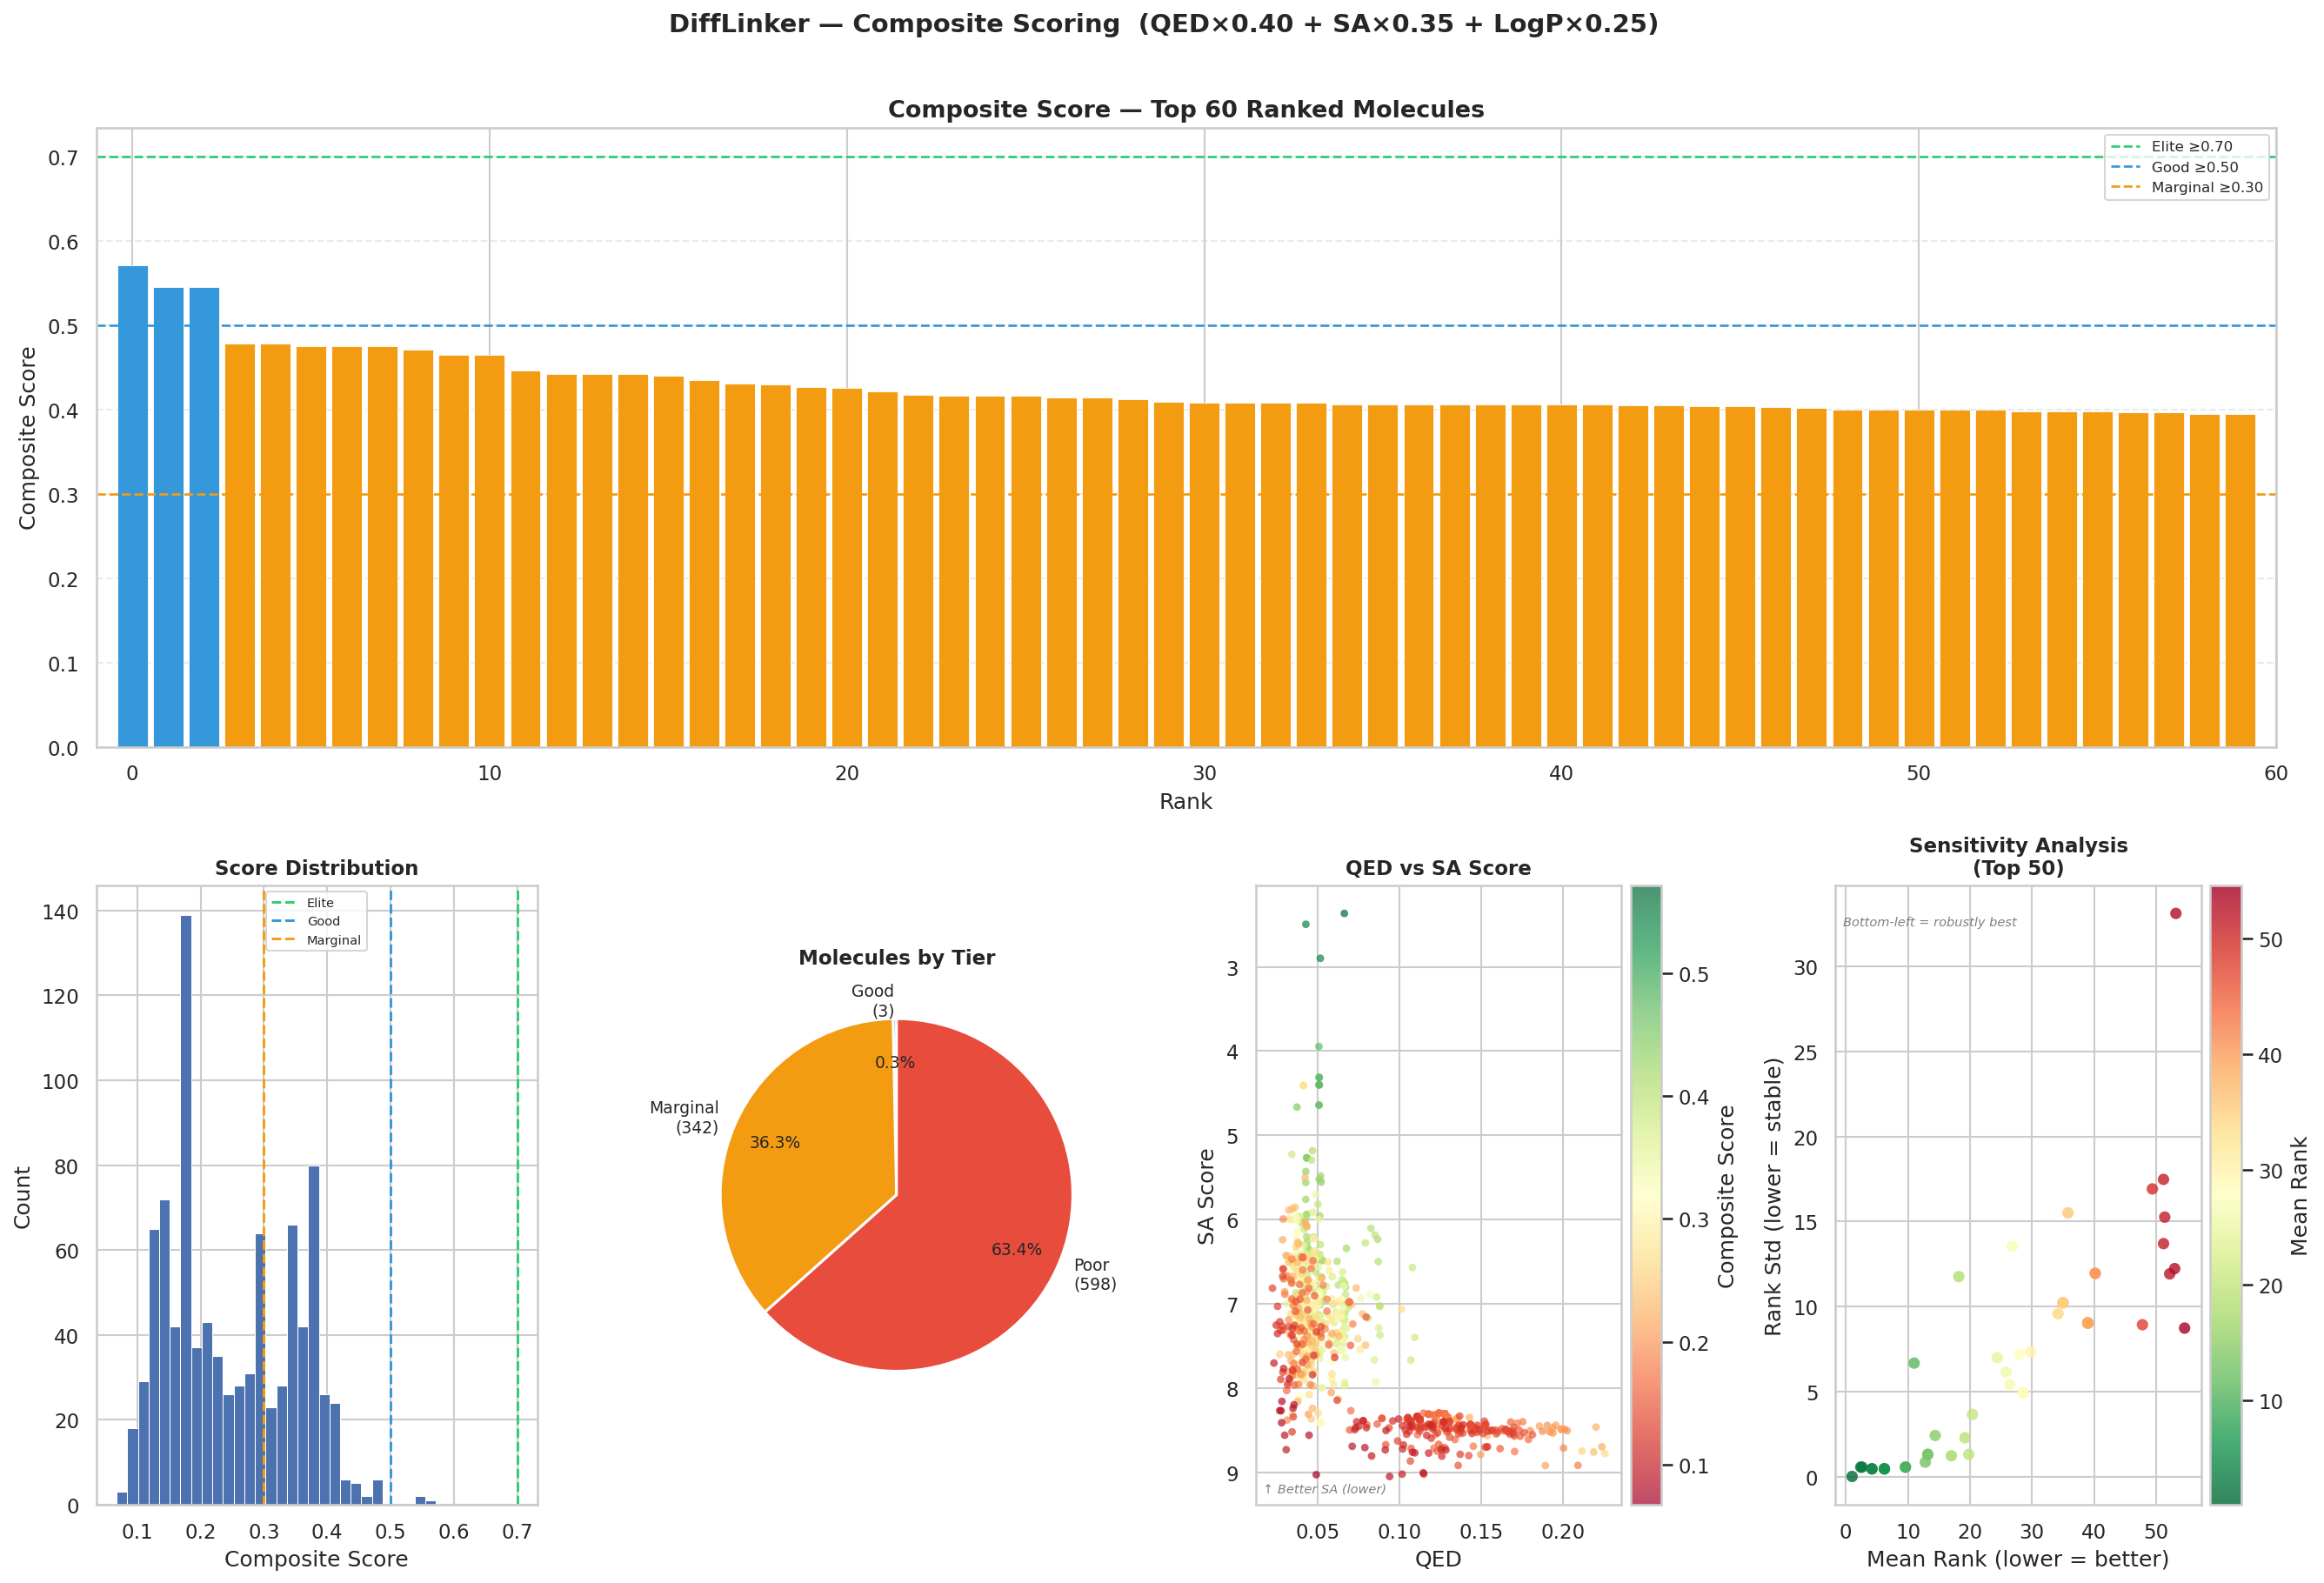


  TOP 20 MOLECULES
 rank                   Molecule      QED       SA    LogP  composite_score     tier
    1 2output_997_Fragments_.xyz 0.066108 2.366629 2.26695         0.571605     Good
    2 2output_369_Fragments_.xyz 0.042547 2.495654 1.84624         0.545849     Good
    3 2output_650_Fragments_.xyz 0.051416 2.899384 2.71074         0.545317     Good
    4 2output_137_Fragments_.xyz 0.050674 4.313279 1.84374         0.478317 Marginal
    4 2output_808_Fragments_.xyz 0.050674 4.313279 1.84374         0.478317 Marginal
    6 2output_751_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
    6  2output_54_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
    6 2output_656_Fragments_.xyz 0.050674 4.400838 1.84374         0.474912 Marginal
    9 2output_975_Fragments_.xyz 0.050519 3.945903 1.41624         0.471508 Marginal
   10 2output_295_Fragments_.xyz 0.050597 4.641365 1.83964         0.465368 Marginal
   10 2output_940_Fragments_.xyz 0.050597 4.6

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

# ── SET YOUR FILE PATH HERE ───────────────────────────────────────────────────
INPUT_FILE  = 'molecule_descriptors_link.csv'
OUTPUT_FILE = 'ranked_moleculesR_link.xlsx'
PLOT_FILE   = 'composite_score_link.png'
# ─────────────────────────────────────────────────────────────────────────────


# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE)
df = df.dropna(subset=['QED', 'SA', 'LogP']).reset_index(drop=True)
print(f'Loaded {len(df)} molecules')


# ── SUB-SCORES ────────────────────────────────────────────────────────────────
df['score_qed']  = df['QED'].clip(0, 1)
df['score_sa']   = (10.0 - df['SA'].clip(1, 10)) / 9.0
df['score_logp'] = np.exp(-((df['LogP'] - 2.5) ** 2) / (2 * 2.0 ** 2))


# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
df['composite_score'] = (
    0.40 * df['score_qed'] +
    0.35 * df['score_sa']  +
    0.25 * df['score_logp']
).round(6)


# ── RANK & TIER ───────────────────────────────────────────────────────────────
df['rank'] = df['composite_score'].rank(ascending=False, method='min').astype(int)
df = df.sort_values('rank').reset_index(drop=True)

TIER_ORDER  = ['Elite', 'Good', 'Marginal', 'Poor']
TIER_COLORS = {'Elite': '#2ecc71', 'Good': '#3498db',
               'Marginal': '#f39c12', 'Poor': '#e74c3c'}

def assign_tier(s):
    if s >= 0.70: return 'Elite'
    if s >= 0.50: return 'Good'
    if s >= 0.30: return 'Marginal'
    return 'Poor'

df['tier'] = df['composite_score'].apply(assign_tier)
tiers_present = [t for t in TIER_ORDER if t in df['tier'].values]


# ── SENSITIVITY ANALYSIS ──────────────────────────────────────────────────────
schemes = {
    'Balanced':   (0.40, 0.35, 0.25),
    'QED-heavy':  (0.60, 0.25, 0.15),
    'SA-heavy':   (0.25, 0.60, 0.15),
    'LogP-heavy': (0.25, 0.25, 0.50),
    'Equal':      (0.333, 0.333, 0.334),
}

rank_df = pd.DataFrame({'Molecule': df['Molecule']})
for name, (wq, ws, wl) in schemes.items():
    s = wq * df['score_qed'] + ws * df['score_sa'] + wl * df['score_logp']
    rank_df[name] = s.rank(ascending=False, method='min').astype(int)

rank_df['rank_mean'] = rank_df[list(schemes.keys())].mean(axis=1).round(1)
rank_df['rank_std']  = rank_df[list(schemes.keys())].std(axis=1).round(2)
rank_df = rank_df.sort_values('rank_mean').reset_index(drop=True)


# ── SAVE EXCEL ────────────────────────────────────────────────────────────────
out_cols = ['rank', 'Molecule', 'QED', 'SA', 'LogP',
            'score_qed', 'score_sa', 'score_logp', 'composite_score', 'tier']

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df[out_cols].to_excel(writer, sheet_name='Ranked', index=False)
    df[out_cols].head(20).to_excel(writer, sheet_name='Top20', index=False)
    summary = (
        df.groupby('tier')[['QED', 'SA', 'LogP', 'composite_score']]
        .describe().round(3)
        .reindex([t for t in TIER_ORDER if t in df['tier'].values])
    )
    summary.to_excel(writer, sheet_name='Tier_Summary')
    rank_df.to_excel(writer, sheet_name='Sensitivity', index=False)

print(f'Saved → {OUTPUT_FILE}')


# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax2 = plt.subplot2grid((2, 4), (1, 0))
ax3 = plt.subplot2grid((2, 4), (1, 1))
ax4 = plt.subplot2grid((2, 4), (1, 2))
ax5 = plt.subplot2grid((2, 4), (1, 3))

# 1 — Ranked bar (top 60)
top60 = df.head(60)
ax1.bar(range(len(top60)), top60['composite_score'],
        color=[TIER_COLORS[t] for t in top60['tier']],
        edgecolor='white', linewidth=0.4, width=0.85)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite ≥0.70'),
                            (0.50, '#3498db', 'Good ≥0.50'),
                            (0.30, '#f39c12', 'Marginal ≥0.30')]:
    ax1.axhline(thresh, color=color, linestyle='--', linewidth=1.3, label=lbl)
ax1.set_title('Composite Score — Top 60 Ranked Molecules',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Composite Score')
ax1.set_xlim(-1, 60)
ax1.legend(fontsize=8, loc='upper right')
ax1.yaxis.grid(True, alpha=0.4, linestyle='--')
ax1.set_axisbelow(True)

# 2 — Score histogram
ax2.hist(df['composite_score'], bins=30, color='#4C72B0',
         edgecolor='white', linewidth=0.5)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite'),
                            (0.50, '#3498db', 'Good'),
                            (0.30, '#f39c12', 'Marginal')]:
    ax2.axvline(thresh, color=color, linestyle='--', linewidth=1.4, label=lbl)
ax2.set_title('Score Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('Composite Score')
ax2.set_ylabel('Count')
ax2.legend(fontsize=7)

# 3 — Tier pie
tier_counts = df['tier'].value_counts().reindex(tiers_present)
ax3.pie(tier_counts.values,
        labels=[f'{t}\n({n})' for t, n in tier_counts.items()],
        colors=[TIER_COLORS[t] for t in tier_counts.index],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9}, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax3.set_title('Molecules by Tier', fontsize=11, fontweight='bold')

# 4 — QED vs SA coloured by composite score
sc = ax4.scatter(df['QED'], df['SA'], c=df['composite_score'],
                 cmap='RdYlGn', s=18, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax4, label='Composite Score', pad=0.02)
ax4.set_xlabel('QED')
ax4.set_ylabel('SA Score')
ax4.set_title('QED vs SA Score', fontsize=11, fontweight='bold')
ax4.invert_yaxis()
ax4.text(0.02, 0.02, '↑ Better SA (lower)', transform=ax4.transAxes,
         fontsize=7, color='grey', style='italic')

# 5 — Sensitivity scatter (rank_mean vs rank_std, top 50)
top50s = rank_df.head(50)
sc2 = ax5.scatter(top50s['rank_mean'], top50s['rank_std'],
                  c=top50s['rank_mean'], cmap='RdYlGn_r',
                  s=40, alpha=0.8, edgecolors='none')
plt.colorbar(sc2, ax=ax5, label='Mean Rank', pad=0.02)
ax5.set_xlabel('Mean Rank (lower = better)')
ax5.set_ylabel('Rank Std (lower = stable)')
ax5.set_title('Sensitivity Analysis\n(Top 50)', fontsize=11, fontweight='bold')
ax5.text(0.02, 0.95, 'Bottom-left = robustly best',
         transform=ax5.transAxes, fontsize=7, color='grey',
         style='italic', va='top')

fig.suptitle('DiffLinker — Composite Scoring  (QED×0.40 + SA×0.35 + LogP×0.25)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=200, bbox_inches='tight')
print(f'Saved → {PLOT_FILE}')
plt.show()


# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print('  TOP 20 MOLECULES')
print(f'{"="*65}')
print(df[['rank', 'Molecule', 'QED', 'SA', 'LogP',
          'composite_score', 'tier']].head(20).to_string(index=False))

print(f'\n{"="*65}')
print('  SENSITIVITY — Top 15  (rank_std ≈ 0 = robust candidate)')
print(f'{"="*65}')
print(rank_df.head(15).to_string(index=False))
print(f'{"="*65}')

Loaded top 10 molecules from ranked_moleculesR_link.xlsx

Successfully converted: 10/10

Saved → top10_molecules_NANP.png


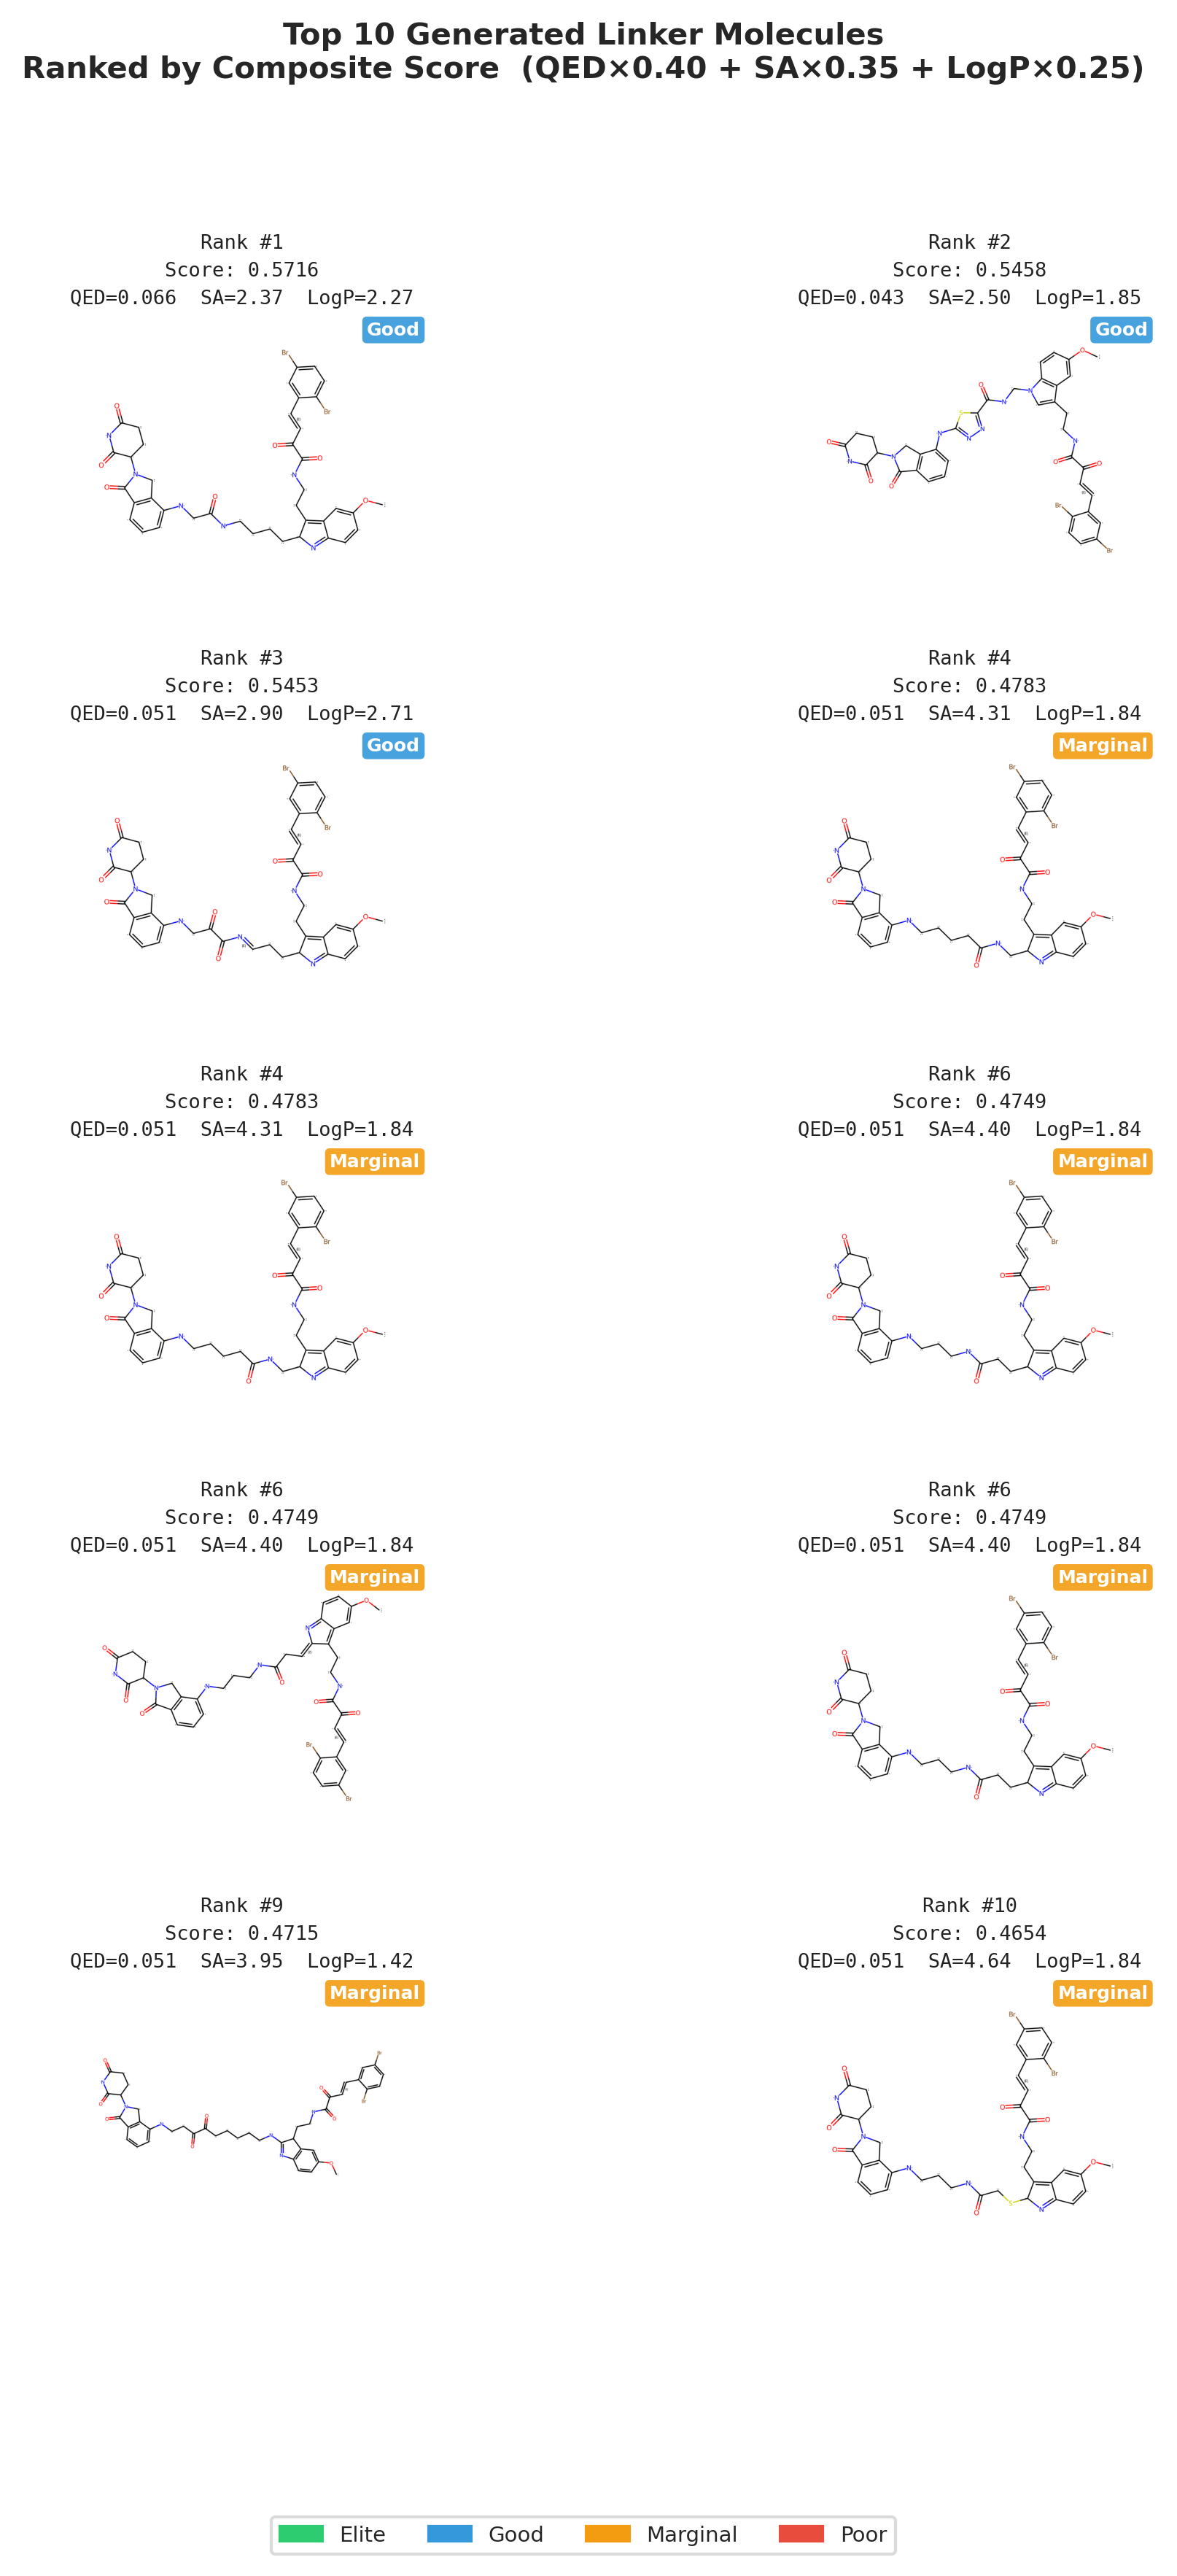

In [22]:
import os
import warnings
warnings.filterwarnings('ignore')

import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import io

from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import rdMolDraw2D

# ── SET YOUR PATHS HERE ───────────────────────────────────────────────────────
RANKED_FILE = 'ranked_moleculesR_link.xlsx'   # output from composite_scoring.py
XYZ_FOLDER  = 'final_R_NA_NP_link/'               # folder containing all .xyz files
OUTPUT_PNG  = 'top10_molecules_NANP.png'
# ─────────────────────────────────────────────────────────────────────────────

TOP_N = 10


# ── LOAD RANKED LIST ──────────────────────────────────────────────────────────
df = pd.read_excel(RANKED_FILE, sheet_name='Top20')
df = df.head(TOP_N).reset_index(drop=True)
print(f'Loaded top {len(df)} molecules from {RANKED_FILE}')


# ── XYZ → RDKIT MOL ───────────────────────────────────────────────────────────
def find_xyz(molecule_name, folder):
    """Find the XYZ file matching the molecule name anywhere in the folder."""
    name = Path(molecule_name).stem if molecule_name.endswith('.xyz') else molecule_name
    matches = list(Path(folder).rglob(f'{name}.xyz'))
    if matches:
        return str(matches[0])
    # fallback: partial match
    for f in Path(folder).rglob('*.xyz'):
        if name in f.stem:
            return str(f)
    return None


def xyz_to_mol(xyz_path):
    """XYZ → SDF via OpenBabel → RDKit Mol with 2D coords for drawing."""
    sdf_path = xyz_path.replace('.xyz', '_tmp.sdf')
    try:
        subprocess.run(
            ['obabel', xyz_path, '-O', sdf_path, '-h'],
            capture_output=True, timeout=20
        )
        if not os.path.exists(sdf_path):
            return None, None
        suppl = Chem.SDMolSupplier(sdf_path, removeHs=True, sanitize=True)
        mols  = [m for m in suppl if m is not None]
        if not mols:
            return None, None
        mol = mols[0]
        # Generate clean 2D coordinates for drawing
        AllChem.Compute2DCoords(mol)
        smiles = Chem.MolToSmiles(mol)
        return mol, smiles
    except Exception as e:
        print(f'  Error converting {xyz_path}: {e}')
        return None, None
    finally:
        if os.path.exists(sdf_path):
            os.remove(sdf_path)


# ── COLLECT MOLS ──────────────────────────────────────────────────────────────
mols, labels = [], []

for _, row in df.iterrows():
    name  = row['Molecule']
    rank  = int(row['rank'])
    score = row['composite_score']
    qed   = row['QED']
    sa    = row['SA']
    logp  = row['LogP']

    xyz_path = find_xyz(name, XYZ_FOLDER)
    if xyz_path is None:
        print(f'  [WARN] XYZ not found for: {name}')
        mols.append(None)
    else:
        mol, smiles = xyz_to_mol(xyz_path)
        if mol is None:
            print(f'  [WARN] Conversion failed: {name}')
        mols.append(mol)

    label = (f'Rank #{rank}\n'
             f'Score: {score:.4f}\n'
             f'QED={qed:.3f}  SA={sa:.2f}  LogP={logp:.2f}')
    labels.append(label)

print(f'\nSuccessfully converted: {sum(m is not None for m in mols)}/{TOP_N}')


# ── DRAW EACH MOLECULE TO PNG BYTES ──────────────────────────────────────────
def mol_to_image(mol, size=(800, 600)):
    """Render a single mol to a PIL Image using RDKit drawer."""
    if mol is None:
        # Blank placeholder
        img = Image.new('RGB', size, color='#f8f8f8')
        return img

    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    drawer.drawOptions().addStereoAnnotation    = True
    drawer.drawOptions().addAtomIndices         = False
    drawer.drawOptions().bondLineWidth          = 2.5
    drawer.drawOptions().atomLabelFontSize      = 0.55
    drawer.drawOptions().padding                = 0.15

    # Clean white background
    drawer.drawOptions().setBackgroundColour((1, 1, 1, 1))

    try:
        rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer.DrawMolecule(mol)
    except Exception:
        drawer.DrawMolecule(mol)

    drawer.FinishDrawing()
    png_bytes = drawer.GetDrawingText()
    return Image.open(io.BytesIO(png_bytes))


# ── COMPOSE A4 FIGURE (2 cols × 5 rows) ──────────────────────────────────────
# A4 at 300 DPI = 2480 × 3508 px
# We use figsize in inches: 8.27 × 11.69
COLS, ROWS = 2, 5
MOL_SIZE   = (900, 650)   # px per molecule panel for rdkit renderer

TIER_COLORS = {'Elite': '#2ecc71', 'Good': '#3498db',
               'Marginal': '#f39c12', 'Poor': '#e74c3c'}

fig, axes = plt.subplots(
    ROWS, COLS,
    figsize=(8.27, 11.69),          # A4 inches
    dpi=300,
    gridspec_kw={'hspace': 0.55, 'wspace': 0.08}
)

for idx in range(ROWS * COLS):
    row_i, col_i = divmod(idx, COLS)
    ax = axes[row_i][col_i]

    if idx >= len(mols):
        ax.axis('off')
        continue

    mol   = mols[idx]
    label = labels[idx]
    tier  = df.iloc[idx]['tier'] if idx < len(df) else 'Poor'
    color = TIER_COLORS.get(tier, '#888888')

    img = mol_to_image(mol, size=MOL_SIZE)

    ax.imshow(img)
    ax.axis('off')

    # Tier-coloured border around each panel
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(3.0)

    # Label below the molecule
    ax.set_title(label,
                 fontsize=6.5,
                 fontfamily='monospace',
                 color='#222222',
                 pad=4,
                 loc='center',
                 linespacing=1.6)

    # Tier badge (top-right corner of axes)
    ax.text(0.98, 0.98, tier,
            transform=ax.transAxes,
            fontsize=6, fontweight='bold',
            color='white',
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.25', fc=color, ec='none', alpha=0.9))


# ── Title & legend ────────────────────────────────────────────────────────────
fig.suptitle('Top 10 Generated Linker Molecules\n'
             'Ranked by Composite Score  (QED×0.40 + SA×0.35 + LogP×0.25)',
             fontsize=10, fontweight='bold', y=0.995, va='top')

# Tier legend patches
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=7, frameon=True, bbox_to_anchor=(0.5, 0.001),
           edgecolor='lightgrey')

plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight',
            facecolor='white', format='png')
print(f'\nSaved → {OUTPUT_PNG}')
plt.show()

Loaded 279 molecules
Saved → ranked_moleculesR_1.xlsx
Saved → composite_score_1.png


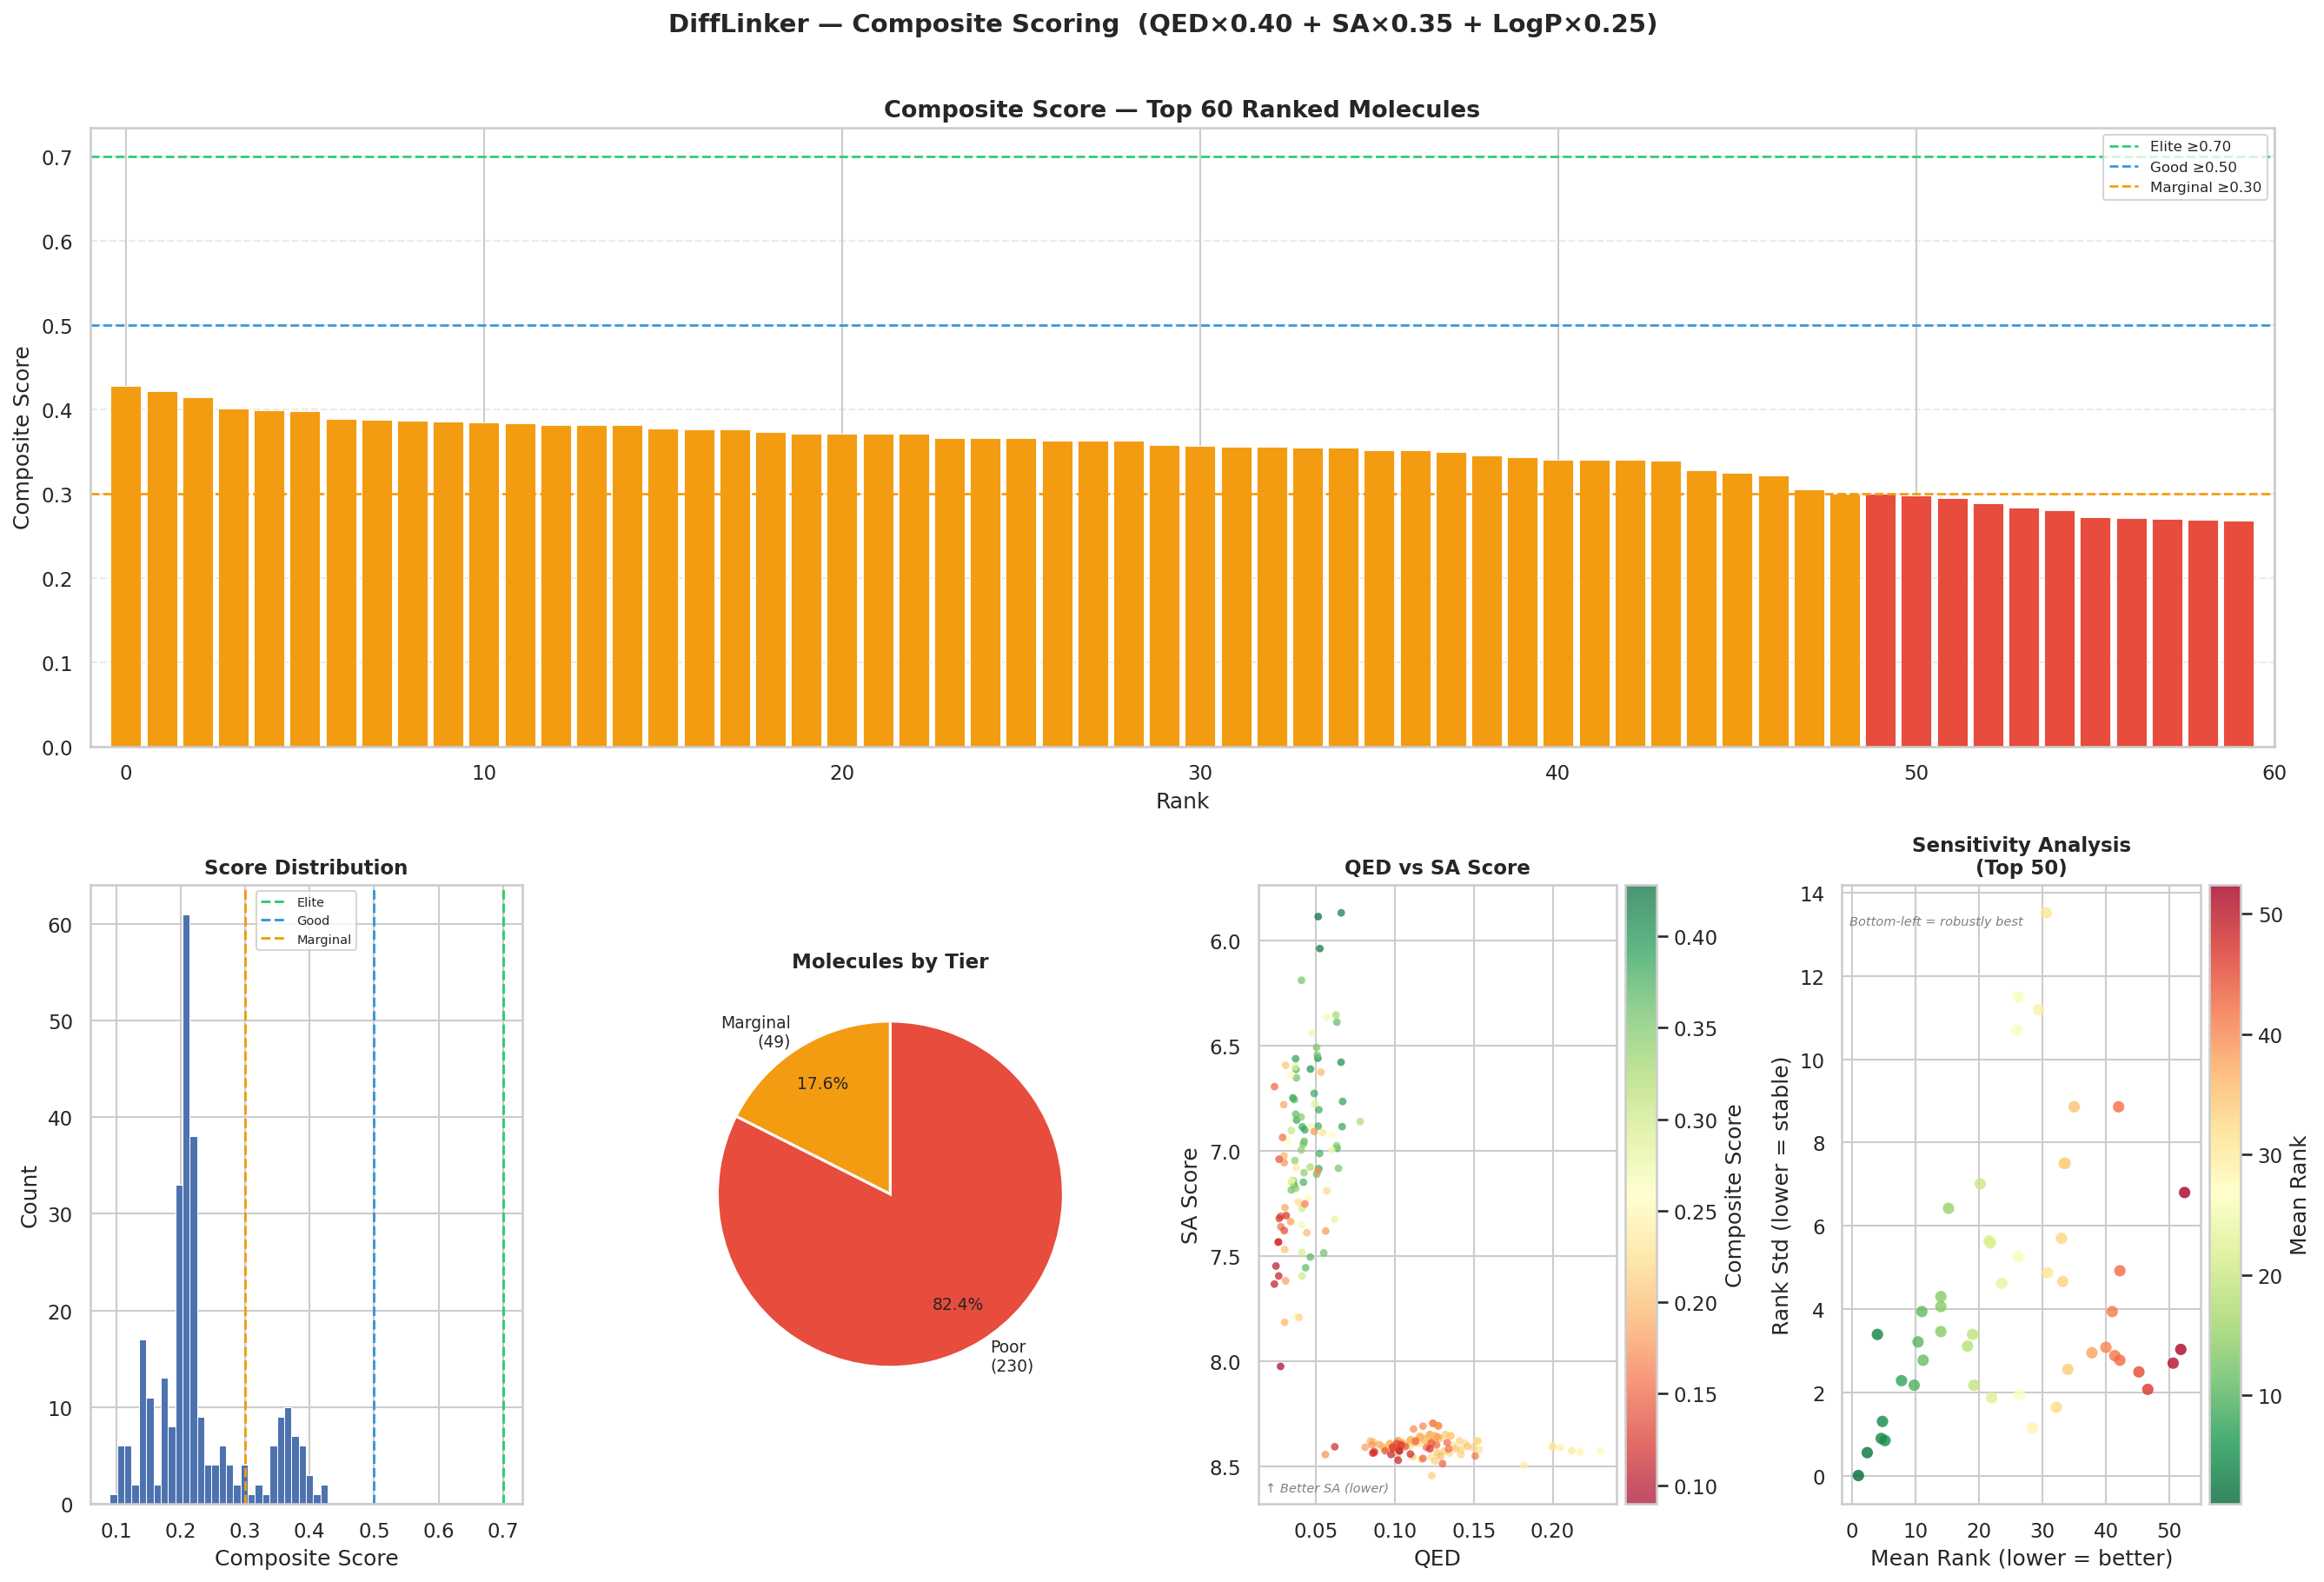


  TOP 20 MOLECULES
 rank                   Molecule      QED       SA    LogP  composite_score     tier
    1 1output_464_Fragments_.xyz 0.051408 5.885487 2.21732         0.428087 Marginal
    2 2output_311_Fragments_.xyz 0.052432 6.037476 2.19083         0.422102 Marginal
    3  1output_13_Fragments_.xyz 0.065988 5.867678 3.37234         0.414412 Marginal
    4 1output_198_Fragments_.xyz 0.065860 6.578241 1.99394         0.401536 Marginal
    5 2output_504_Fragments_.xyz 0.046468 6.610675 2.27154         0.398768 Marginal
    6 1output_169_Fragments_.xyz 0.051197 6.559076 2.93295         0.398503 Marginal
    7 2output_328_Fragments_.xyz 0.035304 6.747912 2.72986         0.388946 Marginal
    8 1output_228_Fragments_.xyz 0.066858 6.764708 1.78703         0.387169 Marginal
    9 1output_176_Fragments_.xyz 0.037080 6.561595 1.88203         0.386894 Marginal
   10 1output_255_Fragments_.xyz 0.042915 6.899618 2.21585         0.385226 Marginal
   11   2output_4_Fragments_.xyz 0.041329 6.8

In [23]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

# ── SET YOUR FILE PATH HERE ───────────────────────────────────────────────────
INPUT_FILE  = 'molecule_descriptors.csv'
OUTPUT_FILE = 'ranked_moleculesR_1.xlsx'
PLOT_FILE   = 'composite_score_1.png'
# ─────────────────────────────────────────────────────────────────────────────


# ── LOAD ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_FILE)
df = df.dropna(subset=['QED', 'SA', 'LogP']).reset_index(drop=True)
print(f'Loaded {len(df)} molecules')


# ── SUB-SCORES ────────────────────────────────────────────────────────────────
df['score_qed']  = df['QED'].clip(0, 1)
df['score_sa']   = (10.0 - df['SA'].clip(1, 10)) / 9.0
df['score_logp'] = np.exp(-((df['LogP'] - 2.5) ** 2) / (2 * 2.0 ** 2))


# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
df['composite_score'] = (
    0.40 * df['score_qed'] +
    0.35 * df['score_sa']  +
    0.25 * df['score_logp']
).round(6)


# ── RANK & TIER ───────────────────────────────────────────────────────────────
df['rank'] = df['composite_score'].rank(ascending=False, method='min').astype(int)
df = df.sort_values('rank').reset_index(drop=True)

TIER_ORDER  = ['Elite', 'Good', 'Marginal', 'Poor']
TIER_COLORS = {'Elite': '#2ecc71', 'Good': '#3498db',
               'Marginal': '#f39c12', 'Poor': '#e74c3c'}

def assign_tier(s):
    if s >= 0.70: return 'Elite'
    if s >= 0.50: return 'Good'
    if s >= 0.30: return 'Marginal'
    return 'Poor'

df['tier'] = df['composite_score'].apply(assign_tier)
tiers_present = [t for t in TIER_ORDER if t in df['tier'].values]


# ── SENSITIVITY ANALYSIS ──────────────────────────────────────────────────────
schemes = {
    'Balanced':   (0.40, 0.35, 0.25),
    'QED-heavy':  (0.60, 0.25, 0.15),
    'SA-heavy':   (0.25, 0.60, 0.15),
    'LogP-heavy': (0.25, 0.25, 0.50),
    'Equal':      (0.333, 0.333, 0.334),
}

rank_df = pd.DataFrame({'Molecule': df['Molecule']})
for name, (wq, ws, wl) in schemes.items():
    s = wq * df['score_qed'] + ws * df['score_sa'] + wl * df['score_logp']
    rank_df[name] = s.rank(ascending=False, method='min').astype(int)

rank_df['rank_mean'] = rank_df[list(schemes.keys())].mean(axis=1).round(1)
rank_df['rank_std']  = rank_df[list(schemes.keys())].std(axis=1).round(2)
rank_df = rank_df.sort_values('rank_mean').reset_index(drop=True)


# ── SAVE EXCEL ────────────────────────────────────────────────────────────────
out_cols = ['rank', 'Molecule', 'QED', 'SA', 'LogP',
            'score_qed', 'score_sa', 'score_logp', 'composite_score', 'tier']

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df[out_cols].to_excel(writer, sheet_name='Ranked', index=False)
    df[out_cols].head(20).to_excel(writer, sheet_name='Top20', index=False)
    summary = (
        df.groupby('tier')[['QED', 'SA', 'LogP', 'composite_score']]
        .describe().round(3)
        .reindex([t for t in TIER_ORDER if t in df['tier'].values])
    )
    summary.to_excel(writer, sheet_name='Tier_Summary')
    rank_df.to_excel(writer, sheet_name='Sensitivity', index=False)

print(f'Saved → {OUTPUT_FILE}')


# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=4)
ax2 = plt.subplot2grid((2, 4), (1, 0))
ax3 = plt.subplot2grid((2, 4), (1, 1))
ax4 = plt.subplot2grid((2, 4), (1, 2))
ax5 = plt.subplot2grid((2, 4), (1, 3))

# 1 — Ranked bar (top 60)
top60 = df.head(60)
ax1.bar(range(len(top60)), top60['composite_score'],
        color=[TIER_COLORS[t] for t in top60['tier']],
        edgecolor='white', linewidth=0.4, width=0.85)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite ≥0.70'),
                            (0.50, '#3498db', 'Good ≥0.50'),
                            (0.30, '#f39c12', 'Marginal ≥0.30')]:
    ax1.axhline(thresh, color=color, linestyle='--', linewidth=1.3, label=lbl)
ax1.set_title('Composite Score — Top 60 Ranked Molecules',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Composite Score')
ax1.set_xlim(-1, 60)
ax1.legend(fontsize=8, loc='upper right')
ax1.yaxis.grid(True, alpha=0.4, linestyle='--')
ax1.set_axisbelow(True)

# 2 — Score histogram
ax2.hist(df['composite_score'], bins=30, color='#4C72B0',
         edgecolor='white', linewidth=0.5)
for thresh, color, lbl in [(0.70, '#2ecc71', 'Elite'),
                            (0.50, '#3498db', 'Good'),
                            (0.30, '#f39c12', 'Marginal')]:
    ax2.axvline(thresh, color=color, linestyle='--', linewidth=1.4, label=lbl)
ax2.set_title('Score Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('Composite Score')
ax2.set_ylabel('Count')
ax2.legend(fontsize=7)

# 3 — Tier pie
tier_counts = df['tier'].value_counts().reindex(tiers_present)
ax3.pie(tier_counts.values,
        labels=[f'{t}\n({n})' for t, n in tier_counts.items()],
        colors=[TIER_COLORS[t] for t in tier_counts.index],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 9}, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax3.set_title('Molecules by Tier', fontsize=11, fontweight='bold')

# 4 — QED vs SA coloured by composite score
sc = ax4.scatter(df['QED'], df['SA'], c=df['composite_score'],
                 cmap='RdYlGn', s=18, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=ax4, label='Composite Score', pad=0.02)
ax4.set_xlabel('QED')
ax4.set_ylabel('SA Score')
ax4.set_title('QED vs SA Score', fontsize=11, fontweight='bold')
ax4.invert_yaxis()
ax4.text(0.02, 0.02, '↑ Better SA (lower)', transform=ax4.transAxes,
         fontsize=7, color='grey', style='italic')

# 5 — Sensitivity scatter (rank_mean vs rank_std, top 50)
top50s = rank_df.head(50)
sc2 = ax5.scatter(top50s['rank_mean'], top50s['rank_std'],
                  c=top50s['rank_mean'], cmap='RdYlGn_r',
                  s=40, alpha=0.8, edgecolors='none')
plt.colorbar(sc2, ax=ax5, label='Mean Rank', pad=0.02)
ax5.set_xlabel('Mean Rank (lower = better)')
ax5.set_ylabel('Rank Std (lower = stable)')
ax5.set_title('Sensitivity Analysis\n(Top 50)', fontsize=11, fontweight='bold')
ax5.text(0.02, 0.95, 'Bottom-left = robustly best',
         transform=ax5.transAxes, fontsize=7, color='grey',
         style='italic', va='top')

fig.suptitle('DiffLinker — Composite Scoring  (QED×0.40 + SA×0.35 + LogP×0.25)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=200, bbox_inches='tight')
print(f'Saved → {PLOT_FILE}')
plt.show()


# ── PRINT SUMMARY ─────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print('  TOP 20 MOLECULES')
print(f'{"="*65}')
print(df[['rank', 'Molecule', 'QED', 'SA', 'LogP',
          'composite_score', 'tier']].head(20).to_string(index=False))

print(f'\n{"="*65}')
print('  SENSITIVITY — Top 15  (rank_std ≈ 0 = robust candidate)')
print(f'{"="*65}')
print(rank_df.head(15).to_string(index=False))
print(f'{"="*65}')

In [29]:
import os
import math
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDetermineBonds


# ============================================================
# HARD-CODE YOUR XYZ FOLDER PATH HERE
# ============================================================

xyz_folder = r"final_R_A_P_1/"


# ============================================================
# TOP 10 FILES
# ============================================================

top_xyz_files = [
    "1output_464_Fragments_.xyz",
    "2output_311_Fragments_.xyz",
    "1output_13_Fragments_.xyz",
    "1output_198_Fragments_.xyz",
    "2output_504_Fragments_.xyz",
    "1output_169_Fragments_.xyz",
    "2output_328_Fragments_.xyz",
    "1output_228_Fragments_.xyz",
    "1output_176_Fragments_.xyz",
    "1output_255_Fragments_.xyz"
]


# ============================================================
# FUNCTION: XYZ -> RDKit molecule
# ============================================================

def xyz_to_mol(xyz_path):
    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            print(f"Failed to read: {xyz_path}")
            return None

        # Determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try determining bond orders
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Generate 2D coordinates
        Chem.rdDepictor.Compute2DCoords(mol)

        return mol

    except Exception as e:
        print(f"Error with {xyz_path}: {e}")
        return None


# ============================================================
# LOAD MOLECULES
# ============================================================

molecules = []
legends = []

for idx, filename in enumerate(top_xyz_files, start=1):

    file_path = os.path.join(xyz_folder, filename)

    mol = xyz_to_mol(file_path)

    if mol is not None:
        molecules.append(mol)

        # Cleaner labels for thesis figure
        legends.append(f"Rank {idx}")


# ============================================================
# DRAW GRID IMAGE
# ============================================================

img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=2,
    subImgSize=(500, 500),
    legends=legends,
    useSVG=False,
    returnPNG=False
)

# ============================================================
# SAVE IMAGE
# ============================================================

output_file = "top10_molecules_grid_link.png"

img.save(output_file)

print(f"\nSaved figure as: {output_file}")


Saved figure as: top10_molecules_grid_link.png


In [32]:
import os
import shutil

# ============================================================
# HARD-CODE YOUR PATHS
# ============================================================

source_folder = r"final_R_NA_P_1/"
destination_folder = r"topmols_NA_P_new"

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# ============================================================
# RANKED FILE LIST
# ============================================================

ranked_files = [
    (1,  "1output_478_Fragments_.xyz"),
    (2,  "1output_205_Fragments_.xyz"),
    (3,  "1output_357_Fragments_.xyz"),
    (4,  "1output_219_Fragments_.xyz"),
    (5,  "2output_411_Fragments_.xyz"),
    (6,  "2output_72_Fragments_.xyz"),
    (7,  "1output_76_Fragments_.xyz"),
    (8,  "1output_510_Fragments_.xyz"),
    (9,  "2output_152_Fragments_.xyz"),
    (10, "2output_316_Fragments_.xyz"),
]

# ============================================================
# COPY + RENAME FILES
# ============================================================

for rank, filename in ranked_files:

    source_path = os.path.join(source_folder, filename)

    # New filename format
    new_filename = f"rank_{rank}_{filename}"

    destination_path = os.path.join(destination_folder, new_filename)

    if os.path.exists(source_path):

        shutil.copy2(source_path, destination_path)

        print(f"Copied: {filename}")
        print(f"   -> {new_filename}")

    else:
        print(f"Missing file: {filename}")

print("\nDone. Your ranked molecular vault is ready.")

Copied: 1output_478_Fragments_.xyz
   -> rank_1_1output_478_Fragments_.xyz
Copied: 1output_205_Fragments_.xyz
   -> rank_2_1output_205_Fragments_.xyz
Copied: 1output_357_Fragments_.xyz
   -> rank_3_1output_357_Fragments_.xyz
Copied: 1output_219_Fragments_.xyz
   -> rank_4_1output_219_Fragments_.xyz
Copied: 2output_411_Fragments_.xyz
   -> rank_5_2output_411_Fragments_.xyz
Copied: 2output_72_Fragments_.xyz
   -> rank_6_2output_72_Fragments_.xyz
Copied: 1output_76_Fragments_.xyz
   -> rank_7_1output_76_Fragments_.xyz
Copied: 1output_510_Fragments_.xyz
   -> rank_8_1output_510_Fragments_.xyz
Copied: 2output_152_Fragments_.xyz
   -> rank_9_2output_152_Fragments_.xyz
Copied: 2output_316_Fragments_.xyz
   -> rank_10_2output_316_Fragments_.xyz

Done. Your ranked molecular vault is ready.


In [33]:
import os
import shutil

# ============================================================
# HARD-CODE YOUR PATHS
# ============================================================

source_folder = r"final_R_A_P_1/"
destination_folder = r"topmols_A_P_fin"

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# ============================================================
# RANKED FILE LIST
# ============================================================

ranked_files = [
    (1,  "1output_464_Fragments_.xyz"),
    (2,  "2output_311_Fragments_.xyz"),
    (3,  "1output_13_Fragments_.xyz"),
    (4,  "1output_198_Fragments_.xyz"),
    (5,  "2output_504_Fragments_.xyz"),
    (6,  "1output_169_Fragments_.xyz"),
    (7,  "2output_328_Fragments_.xyz"),
    (8,  "1output_228_Fragments_.xyz"),
    (9,  "1output_176_Fragments_.xyz"),
    (10, "1output_255_Fragments_.xyz"),
]

# ============================================================
# COPY + RENAME FILES
# ============================================================

for rank, filename in ranked_files:

    source_path = os.path.join(source_folder, filename)

    # New filename format
    new_filename = f"rank_{rank}_{filename}"

    destination_path = os.path.join(destination_folder, new_filename)

    if os.path.exists(source_path):

        shutil.copy2(source_path, destination_path)

        print(f"Copied: {filename}")
        print(f"   -> {new_filename}")

    else:
        print(f"Missing file: {filename}")

print("\nDone. Your ranked molecular vault is ready.")

Copied: 1output_464_Fragments_.xyz
   -> rank_1_1output_464_Fragments_.xyz
Copied: 2output_311_Fragments_.xyz
   -> rank_2_2output_311_Fragments_.xyz
Copied: 1output_13_Fragments_.xyz
   -> rank_3_1output_13_Fragments_.xyz
Copied: 1output_198_Fragments_.xyz
   -> rank_4_1output_198_Fragments_.xyz
Copied: 2output_504_Fragments_.xyz
   -> rank_5_2output_504_Fragments_.xyz
Copied: 1output_169_Fragments_.xyz
   -> rank_6_1output_169_Fragments_.xyz
Copied: 2output_328_Fragments_.xyz
   -> rank_7_2output_328_Fragments_.xyz
Copied: 1output_228_Fragments_.xyz
   -> rank_8_1output_228_Fragments_.xyz
Copied: 1output_176_Fragments_.xyz
   -> rank_9_1output_176_Fragments_.xyz
Copied: 1output_255_Fragments_.xyz
   -> rank_10_1output_255_Fragments_.xyz

Done. Your ranked molecular vault is ready.
